# IMPORTS, CONSTANTS AND FUNCTIONS

In [1]:
# Import all necessaty libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
from scipy.signal import butter, lfilter, medfilt, find_peaks, freqz

In [2]:
# Define All Constants

# 10msec Frame Length with 25% overlap (for 16kHz Sampling Rate)
FRAME_LENGTH = 160    # In Samples
HOP_LENGTH = 40       # In Samples

# 30msec Frame Length with 33.3% overlap, used for Pitch Detection
PITCH_FRAME_LENGTH = 480
PITCH_HOP_LENGTH = 160

# For the Linear Filters
CUTOFF_HP = 200       # In Hertz

# For the Median Filter
KSIZE = 17            # Order

In [3]:
# This function creates the spectogram using 2 functions (librosa.amplitude_to_db() and librosa.power_to_db())
def create_spectogram(signal, n_fft, hop_length, win_length, win_type):
    D = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=win_type)
    S_amp_db = librosa.amplitude_to_db(S=np.abs(D), ref=np.max)
    S_pow_db = librosa.power_to_db(np.abs(D)**2)
    return S_amp_db, S_pow_db

# This function creates the plots of the spectograms
def plot_spectogram(amp_signal, pow_signal, title):
    plt.figure(figsize=(16, 5))
    plt.suptitle(title)

    plt.subplot(1, 2, 1)
    librosa.display.specshow(amp_signal, x_axis='time', y_axis='linear')
    plt.colorbar(format='%+2.0f dB')

    plt.subplot(1, 2, 2)
    librosa.display.specshow(pow_signal, x_axis='time', y_axis='linear')
    plt.colorbar(format='%+2.0f dB')

    plt.show()

In [4]:
# Create and Apply a Linear Filter (Lowpass or Highpass)
def linear_filter(signal, cutoff, fs, type, order):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype=type, analog=False)
    y = lfilter(b, a, signal)
    return y

# This function is applying a median filter to a signal for smoothing
def median_filter(energy_signal, zc_signal, ksize):
    smooth_energy_output = medfilt(energy_signal, kernel_size=ksize)
    smooth_zc_output = medfilt(zc_signal, kernel_size=ksize)
    return smooth_energy_output, smooth_zc_output

In [5]:
# Create the Function that Calculates the Short-Time log Energy
# It takes as input the signal for which you want to find the Short-Time log energy, the length of the frame in samples,
#   the hop length in samples and the window which will be applied in each frame
# It returns the energy of each frame both in linear and log scale

def short_time_log_energy_func(signal, FRAME_LENGTH, HOP_LENGTH, window_func):
    # Create the frames and store them in an array
    frames = librosa.util.frame(signal, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)

    # Initialize the values after window application
    windowed_frames = np.zeros((frames.shape[0], frames.shape[1]))

    # Pass each frame through the window
    for i in range(frames.shape[1]):
        windowed_frames[:, i] = frames[:, i] * window_func
        
    # Compute the Energy of each Frame
    speech_energy = np.sum(windowed_frames**2, axis=0)
    
    # y-axis -> short time energy in dB, with max value 0
    tol = 10**(-5) # Just to avoid log(0)
    positive_speech_energy = tol + speech_energy
    log_speech_energy = 10 * np.log10(positive_speech_energy)

    # Normalize Energy using the formula log(En) = log(En) - max(log(En))
    max_log_value = np.max(log_speech_energy)
    log_speech_energy_db = log_speech_energy - max_log_value
    
    return speech_energy, log_speech_energy_db

In [6]:
# Create the Function that calculates the Short-Time Zero Crossings (eg Zero Crossings of each Frame)
# It will take as input the signal for which you want to find the zero crossings, the length of each frame and the hop length (obviously both of them in samples)
# Usually, only the rectangular window is used when you want to find the zero crossings

def short_time_zero_crossings_func(signal, FRAME_LENGTH, HOP_LENGTH):
    # Create the frames and store them in an array
    frames = librosa.util.frame(signal, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)

    # Initialize the list that will contain the number of zero crossings per frame
    speech_zc = np.zeros(frames.shape[1])

    # Find the zero crossings of each frame and store the to the speech_zc array
    for i in range(frames.shape[1]):
        speech_zc[i] = np.sum(librosa.zero_crossings(frames[:, i]))
    
    # Normalize the previous array using the formula Zn = Zn * (R / 2L), wher R == HOP_LENGTH and L == FRAME_LENGTH
    speech_zc_normalized = speech_zc * HOP_LENGTH / FRAME_LENGTH

    return speech_zc, speech_zc_normalized

In [7]:
# This function is used to classify some frames as Voiced or Unvoiced
# The classification as unvoiced will be with the zero crossing rate criterion, while for the voiced with the log energy criterion
# I will give higher priority to the zero crossing rate criterion, which means that if a frame belongs in both classes, it will be classified as Unvoiced

def voiced_unvoiced_frame_classification(frame_num, speech_zc, log_speech_energy_db, IZCT, ITR):
    unvoiced = []
    voiced_temp = [] # It is a temporary array
    voiced = []

    # Clssify each frame that exceeds IZCT as in Zero Crossings as Unvoiced
    for i in range(len(frame_num)):
        if speech_zc[i] > IZCT:
            unvoiced.append(frame_num[i]) # Append the number of the frame, not the value

    # Now classify each frame that exceeds the ITR limit in log Energy as Voiced
    for i in range(len(frame_num)):
        if log_speech_energy_db[i] > ITR:
            voiced_temp.append(frame_num[i])
            
    # Check for frames that have been classified both Voiced and Unvoiced using set theory
    duplicates = set(voiced_temp) & set(unvoiced) # The intersection of the 2 arrays
    
    # If there are frames in both arrays => remove them from the voiced array => Classify them as unvoiced
    if len(duplicates) > 0: # If there are common elements in both arrays, their intersection length won't be zero
        voiced_set = set(voiced_temp) - duplicates

        # Convert set back to a list
        voiced = sorted(list(voiced_set))
        return unvoiced, voiced
    
    return unvoiced, voiced_temp

In [8]:
# This function assignes samples to Voiced or Unvoiced and it is called seperately for voiced and unvoiced frames
# It takes as input the frame_arr, which is an array that contains frame numbers, and the known FRAME_LENGTH and HOP_LENGTH constants
# It is called after the 'voiced_unvoiced_frame_classification' to match a frame with the sample that contains

def classify_samples(frame_arr, FRAME_LENGTH, HOP_LENGTH):
    sample_arr = []

    # Initialize sample_arr array
    frame_begin = HOP_LENGTH * (frame_arr[0]-1)
    frame_end = HOP_LENGTH * (frame_arr[0]-1) + FRAME_LENGTH
    for j in range(FRAME_LENGTH):
        sample_arr.append(frame_begin+j)

    for i in range(len(frame_arr)-1):
        frame_begin = HOP_LENGTH * (frame_arr[i+1]-1) # I have already used the 0-th index
        frame_end = HOP_LENGTH * (frame_arr[i+1]-1) + FRAME_LENGTH
            
        # Useful constants to deal with overlapping frames
        const1 = frame_end - HOP_LENGTH
        const2 = frame_end - 2*HOP_LENGTH
        const3 = frame_end - 3*HOP_LENGTH
        
        # Further check for overlapping frames
        if frame_begin in sample_arr:
                    
            if ((const1-1) in sample_arr):
                for j in range(HOP_LENGTH):
                    sample_arr.append(const1+j)
                continue # If a frame belongs here, it will belong to next if statements too => We do not want it

            if ((const2-1) in sample_arr):
                for j in range(2*HOP_LENGTH):
                    sample_arr.append(const2+j)
                continue # We have the same restriction here too
                    
            if ((const3-1) in sample_arr):
                for j in range(3*HOP_LENGTH):
                    sample_arr.append(const3+j)
                    
        # Just append if the frames ar not overlapping
        else:
            for j in range(FRAME_LENGTH):
                sample_arr.append(frame_begin+j)  
                
    return sample_arr

In [9]:
# This algorithm discriminates speech from background noise
# It takes as inputs a log-energy signal, a zero crossing signal along with the 3 constants ITU, ITR and IZCT
# And it returns the begin point and end point in each step

def speech_silence_discrimination_func(energy, zc, ITU, ITR, IZCT):
    
    # Initialize the begin and end point
    B1, E1 = -1, -1

    # Define the Begin Frame => A frame for which its energy exceed ITR, and then ITU before falls down to ITR
    for i in range(energy.size):
        if energy[i] > ITR:
            for j in range(i, len(energy)):
                if energy[j] < ITR: # If a frame won't exceed ITU before falling down to ITR, continue searching without defining any begin frame
                    break
                elif energy[j] > ITU:
                    B1 = i
        if B1 != -1:
            break
                
    # Define the End Frame with a same way, but searching backwards
    for i in range(energy.size - 1, 0, -1):
        if energy[i] > ITR:
            for j in range(i, 0, -1):
                if energy[j] < ITR: # If a frame won't exceed ITU before falling down to ITR, continue searching without defining any begin frame
                    break
                elif energy[j] > ITU:
                    E1 = i
        if E1 != -1:
            break
        
    # Adjust the B1 and E1 based on the Zero Crossings
    num_of_zcs = 0
    B2, E2 = B1, E1

    for i in range(B1, B1-25, -1):
        if zc[i] > IZCT:
            num_of_zcs = num_of_zcs + 1
            B2 = i 
        
    if num_of_zcs < 4:
        B2 = B1
        
    num_of_zcs = 0
    for i in range(E1, E1+25):
        if zc[i] > IZCT:
            num_of_zcs = num_of_zcs + 1
            E2 = i

    if num_of_zcs < 4:
        E2 = E1
        
    return B1, E1, B2, E2

In [10]:
# This function will be used to clip the signal for the pitch detection (eg, to eliminate lower frequencies that won't need in autocorrelation)
# It takes as input the speech signal along with frame and hop length, and it returns the clipped signal before and after autocorrelation

def center_clipping_func(signal, frame_length, hop_length):
    # Frame the original signal
    frames = librosa.util.frame(signal, frame_length=frame_length, hop_length=hop_length)
    
    # Now, I will split each frame into 3 equally seperated regions, I will find the maximum absolute peak of 1st and 3rd regions,
    #     and I will use the smaller of these peaks to define the clipping

    split_frames = np.split(frames, indices_or_sections=3, axis=0)

    first_frame_value = np.max(np.abs(split_frames[0]), axis=0)
    third_frame_value = np.max(np.abs(split_frames[2]), axis=0)
    min_frame_value = np.minimum(first_frame_value, third_frame_value)
    
    # Now, I will multiply the min_frame_value with a fixed percantage (80%), and this is going to be my clipping level
    clipping_level = min_frame_value * 0.8
    
    # Create the clipped signal, which will contain: +1, if signal >= clipping level, -1 if signal <= clipping level,
    #     and 0 otherwise (if the signal does not exceed the absolute clipping level value)
    # The clipping level is not constant during the whole duration of the signal, it is constant only inside a specific frame
    
    clipped_signal = np.zeros((frames.shape[0], frames.shape[1]))
    for i in range(frames.shape[1]):
        for j in range(frames.shape[0]):
            if frames[j, i] >= clipping_level[i]:
                clipped_signal[j, i] = 1
            elif frames[j, i] <= -1*clipping_level[i]:
                clipped_signal[j, i] = -1
                
    # Now, I have stored the clipped signal into a 2D array, where each row contains the clipped values for each frame
    # So, I will use the autocorrelation function from librosa library, to find the autocorrelation of this 2D array FOR EACH COLUMN (axis=0)
    autocorr_clipped_signal = librosa.autocorrelate(clipped_signal, axis=0)
    
    # Return clipped signal before and after autocorrelation           
    return clipped_signal, autocorr_clipped_signal
    

In [11]:
# This function cretaes and returns two pxp autocorrelation matrices (one for the voiced segmant and one for the unvoiced segment)
# It takes as inputs the voiced and unvoiced matrices for which we would like to compute the autocorrelation matrices
#     and the size p of the arrays (usually p << len((un)voiced))

def create_autocorrelation_matrices(voiced, unvoiced, p):
    
    voiced_autocorr_array = librosa.autocorrelate(voiced, max_size=(p+1))
    unvoiced_autocorr_array = librosa.autocorrelate(unvoiced, max_size=(p+1))
    
    # Create the Toeplitz autocorrelation matrices for both unvoiced and voiced segments
    toeplitz_voiced_array = np.zeros((p, p))
    toeplitz_unvoiced_array = np.zeros((p, p))
    
    for i in range(p):
        toeplitz_voiced_array[i, i:] = voiced_autocorr_array[:p-i]
        toeplitz_voiced_array[i:, i] = voiced_autocorr_array[:p-i]
        
        toeplitz_unvoiced_array[i, i:] = unvoiced_autocorr_array[:p-i]
        toeplitz_unvoiced_array[i:, i] = unvoiced_autocorr_array[:p-i]
        
    # Create the target vectors
    voiced_target_vector = []
    unvoiced_target_vector = []
    
    for i in range(1, p+1, 1):
        voiced_target_vector.append(voiced_autocorr_array[i])
        unvoiced_target_vector.append(unvoiced_autocorr_array[i])
        
    return toeplitz_voiced_array, toeplitz_unvoiced_array, np.array(voiced_target_vector), np.array(unvoiced_target_vector) # Do not return lists, only arrays

In [12]:
# This function computes the MSE to evaluate the LPC Model
def compute_mse(energy, signal, target, p):
    residual = 0
    for i in range(p):
        residual += signal[i] * target[i]
    mse = energy - residual
    return mse

In [13]:
# Compute the Magnitude of the Frequency Responce of the All-Pole Transfer Function H(z)
def all_pole_transfer_func(coef, gain):
    # I need to change a little bit the form of my coefficients in the denominator
    a = np.concatenate([[1], -np.array(coef)])
    w, h = freqz(gain, a, worN=512)
    h_magn = np.abs(h)
    return w, h_magn

# CODE

In [14]:
# Load and hear the speech signal
speech_signal, sr = librosa.load("wav_files/name.wav", sr=16000)
ipd.Audio("wav_files/name.wav")

In [15]:
# Some of the first samples contain nothing => Remove them
print(np.sum(speech_signal[:2560]))

# Slice the first 2.560 samples
speech_signal_sliced = speech_signal[2560:]

0.0


In [16]:
# Useful Prints (on the Sliced Signal)
print(f"Total Samples: {speech_signal_sliced.size}")
print(f"The Highest Energy of a Single Sample is: {np.max(speech_signal_sliced):6f}")
print(f"And the Index of this Sample is: {np.argmax(speech_signal_sliced)}")
# Duration in Seconds of 1 Sample and Total Speech Duration
sample_duration = 1 / sr
duration = 1 / sr * len(speech_signal_sliced)
print(f"One sample lasts for {sample_duration:6f} seconds")
print(f"The audio lasts for {duration} seconds")

Total Samples: 45824
The Highest Energy of a Single Sample is: 0.829346
And the Index of this Sample is: 34965
One sample lasts for 0.000063 seconds
The audio lasts for 2.864 seconds


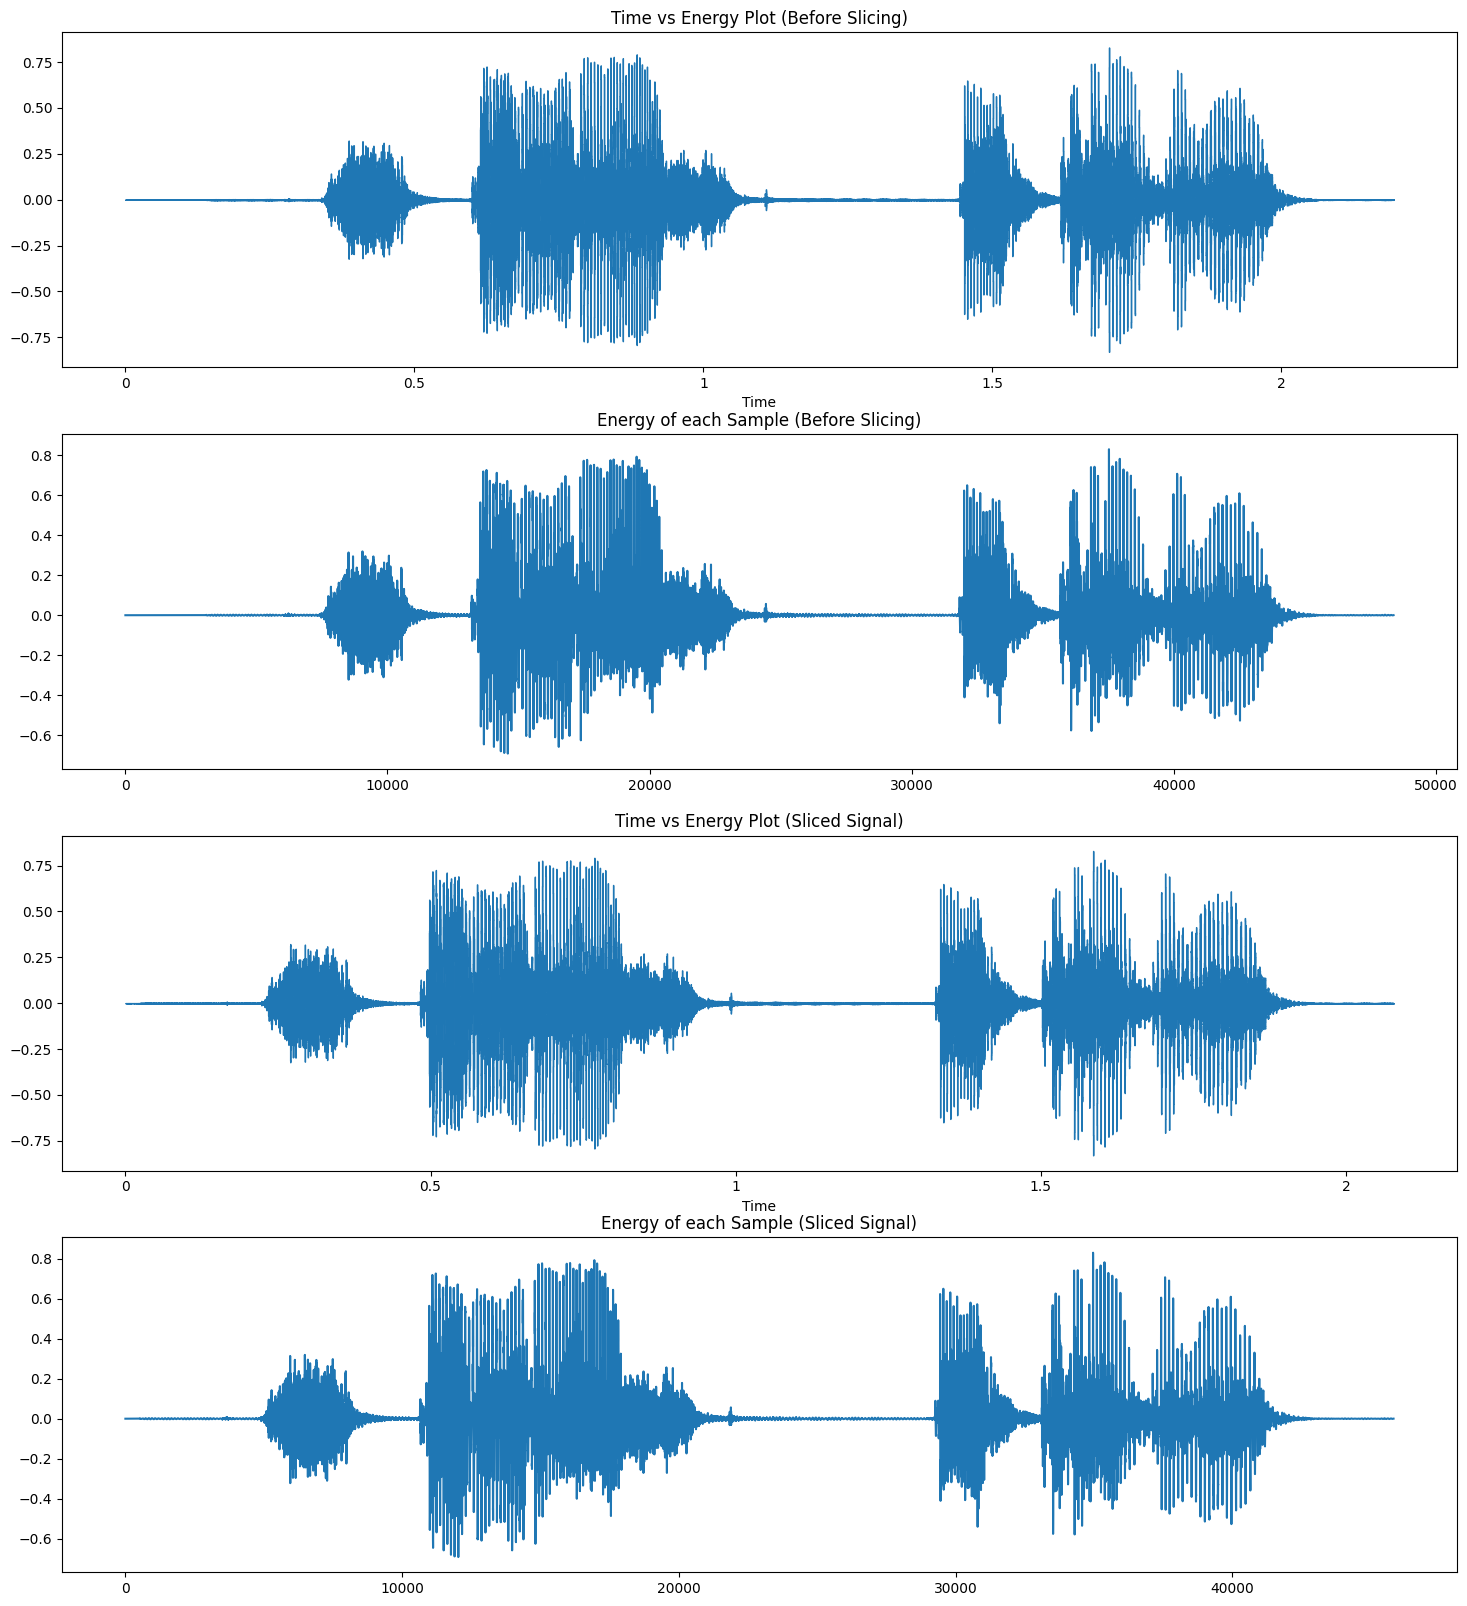

In [17]:
# Plot the Recorded Signal in Time Domain
plt.figure(figsize=(18, 20))

plt.subplot(4, 1, 1)
librosa.display.waveshow(speech_signal)
plt.title("Time vs Energy Plot (Before Slicing)")

plt.subplot(4, 1, 2)
pd.Series(speech_signal).plot()
plt.title("Energy of each Sample (Before Slicing)")

plt.subplot(4, 1, 3)
librosa.display.waveshow(speech_signal_sliced)
plt.title("Time vs Energy Plot (Sliced Signal)")

plt.subplot(4, 1, 4)
pd.Series(speech_signal_sliced).plot()
plt.title("Energy of each Sample (Sliced Signal)")

plt.show()

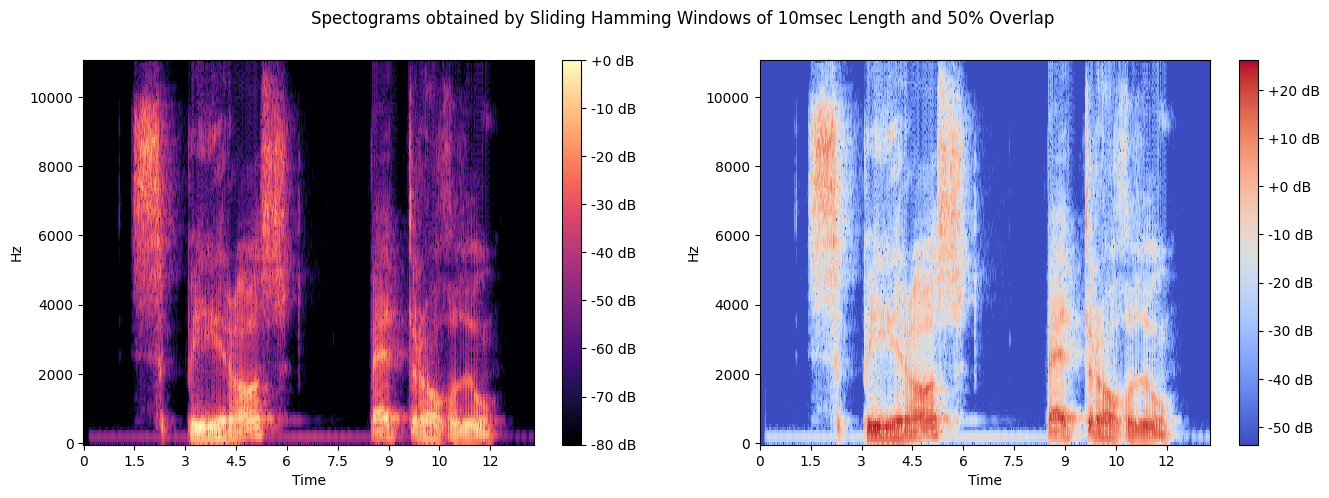

In [18]:
# Spectogram using a Hamming window with duration of 10msec
S10_msec_amp, S10_msec_pow = create_spectogram(speech_signal_sliced, 256, 80, 160, "hamming") 
plot_spectogram(S10_msec_amp, S10_msec_pow, "Spectograms obtained by Sliding Hamming Windows of 10msec Length and 50% Overlap")

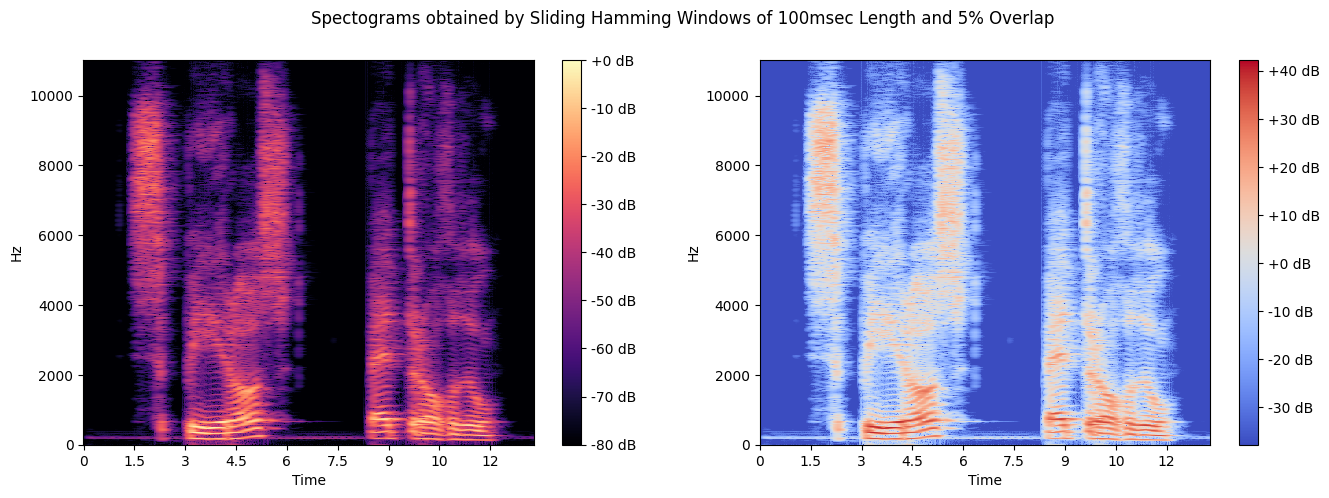

In [19]:
# Spectogram using a Hamming window with duration of 100msec
S100_msec_amp, S100_msec_pow = create_spectogram(speech_signal_sliced, 2048, 80, 1600, "hamming")
plot_spectogram(S100_msec_amp, S100_msec_pow, "Spectograms obtained by Sliding Hamming Windows of 100msec Length and 5% Overlap")

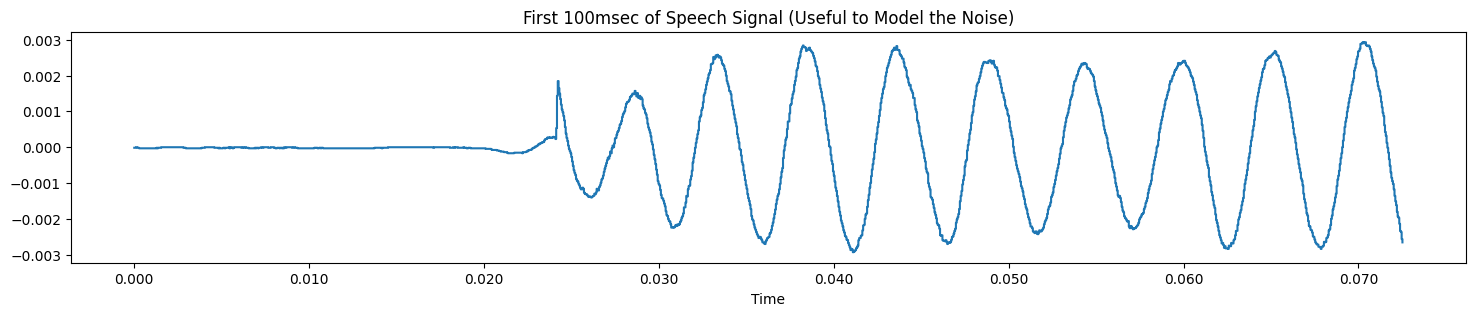

In [20]:
# Model the noise distribution by examining and extreacting statistical values from the first 100msec of the signal

# Isolate the first 100msec of the speech. 100msec interval correspond to 1600 samples in 16kHz sampling rate
noise_interval = speech_signal_sliced[:1600]

# Compute the Short Time log Energy and Short Time Zero Crossings on this interval
noise_energy, log_noise_energy_db = short_time_log_energy_func(noise_interval, FRAME_LENGTH, HOP_LENGTH, np.hamming(FRAME_LENGTH))
noise_zc, noise_zc_normalized = short_time_zero_crossings_func(noise_interval, FRAME_LENGTH, HOP_LENGTH)

# Take the Mean and Standard Deviation of this Interval.
eavg = np.mean(log_noise_energy_db)
esig = np.std(log_noise_energy_db)
zcavg = np.mean(noise_zc)
zcsig = np.std(noise_zc)

# Plot it to verify that there is no speech in this interval
plt.figure(figsize=(18, 3))
librosa.display.waveshow(noise_interval)
plt.title("First 100msec of Speech Signal (Useful to Model the Noise)")
plt.show()

In [21]:
# You can also hear it to verify
ipd.Audio(noise_interval, rate=sr)

In [22]:
# Compute the constants IZCT, ITU and ITR
IF = 35
ITU = -14 # In dB. It should be between -10 and -20 dB

IZCT = max(IF, zcavg+3*zcsig)
ITR = max(ITU-10, -20*np.log10(np.abs(eavg+3*esig))) # Converted to dB scale

print(f"Zero Crossing Threshold: {IZCT:6f}")
print(f"Lower Energy Threshold: {ITR:6f}")

Zero Crossing Threshold: 35.000000
Lower Energy Threshold: -21.904830


In [23]:
# Apply the high-pass filter
clear_speech_signal = linear_filter(speech_signal_sliced, CUTOFF_HP, sr, 'high', 5)

# Hear the Filtered Signal
ipd.Audio(clear_speech_signal, rate=sr)

In [24]:
# Call the Functions with the appropriate arguments and print necessary values
speech_energy, log_speech_energy_db = short_time_log_energy_func(clear_speech_signal, FRAME_LENGTH, HOP_LENGTH, np.hamming(FRAME_LENGTH))
speech_zc, speech_zc_normalized = short_time_zero_crossings_func(clear_speech_signal, FRAME_LENGTH, HOP_LENGTH)

# Some Useful Prints
print(f"Name Energy: {speech_energy[30:34]}")
print(f"Shape of Name Energy: {speech_energy.shape}")
print(f"Name Energy in dB: {log_speech_energy_db[30:34]}")
print(f"This MUST be zero: {np.max(log_speech_energy_db)}")
print("\n##\n")
print(f"Shape of Zero Crossings: {speech_zc.shape}")
print(f"First 30 Values of Zero Crossings Array: \n{speech_zc[0:30]}")
print(f"\nFirst 30 Values of  Normalized Zero Crossings Array: \n{speech_zc_normalized[0:30]}")

# Construct the x-axis of the plot (you can take speech_zc as well since the R, L are the same for both metrics)
frame_num = np.linspace(1, speech_energy.shape[0], speech_energy.shape[0]).astype(int)
#frame_num = np.linspace(1, speech_zc.shape[0], speech_zc.shape[0]).astype(int)

Name Energy: [2.41973082e-06 2.18986325e-06 2.66841533e-06 5.93009938e-06]
Shape of Name Energy: (1142,)
Name Energy in dB: [-59.29526172 -59.37639522 -59.20916063 -58.21419871]
This MUST be zero: 0.0

##

Shape of Zero Crossings: (1142,)
First 30 Values of Zero Crossings Array: 
[22. 25. 32. 28. 20. 14.  9. 19. 29. 38. 38. 28. 17.  6.  4.  4.  4.  5.
  6.  6.  6.  5.  4.  4.  3.  4.  6.  6.  8. 10.]

First 30 Values of  Normalized Zero Crossings Array: 
[5.5  6.25 8.   7.   5.   3.5  2.25 4.75 7.25 9.5  9.5  7.   4.25 1.5
 1.   1.   1.   1.25 1.5  1.5  1.5  1.25 1.   1.   0.75 1.   1.5  1.5
 2.   2.5 ]


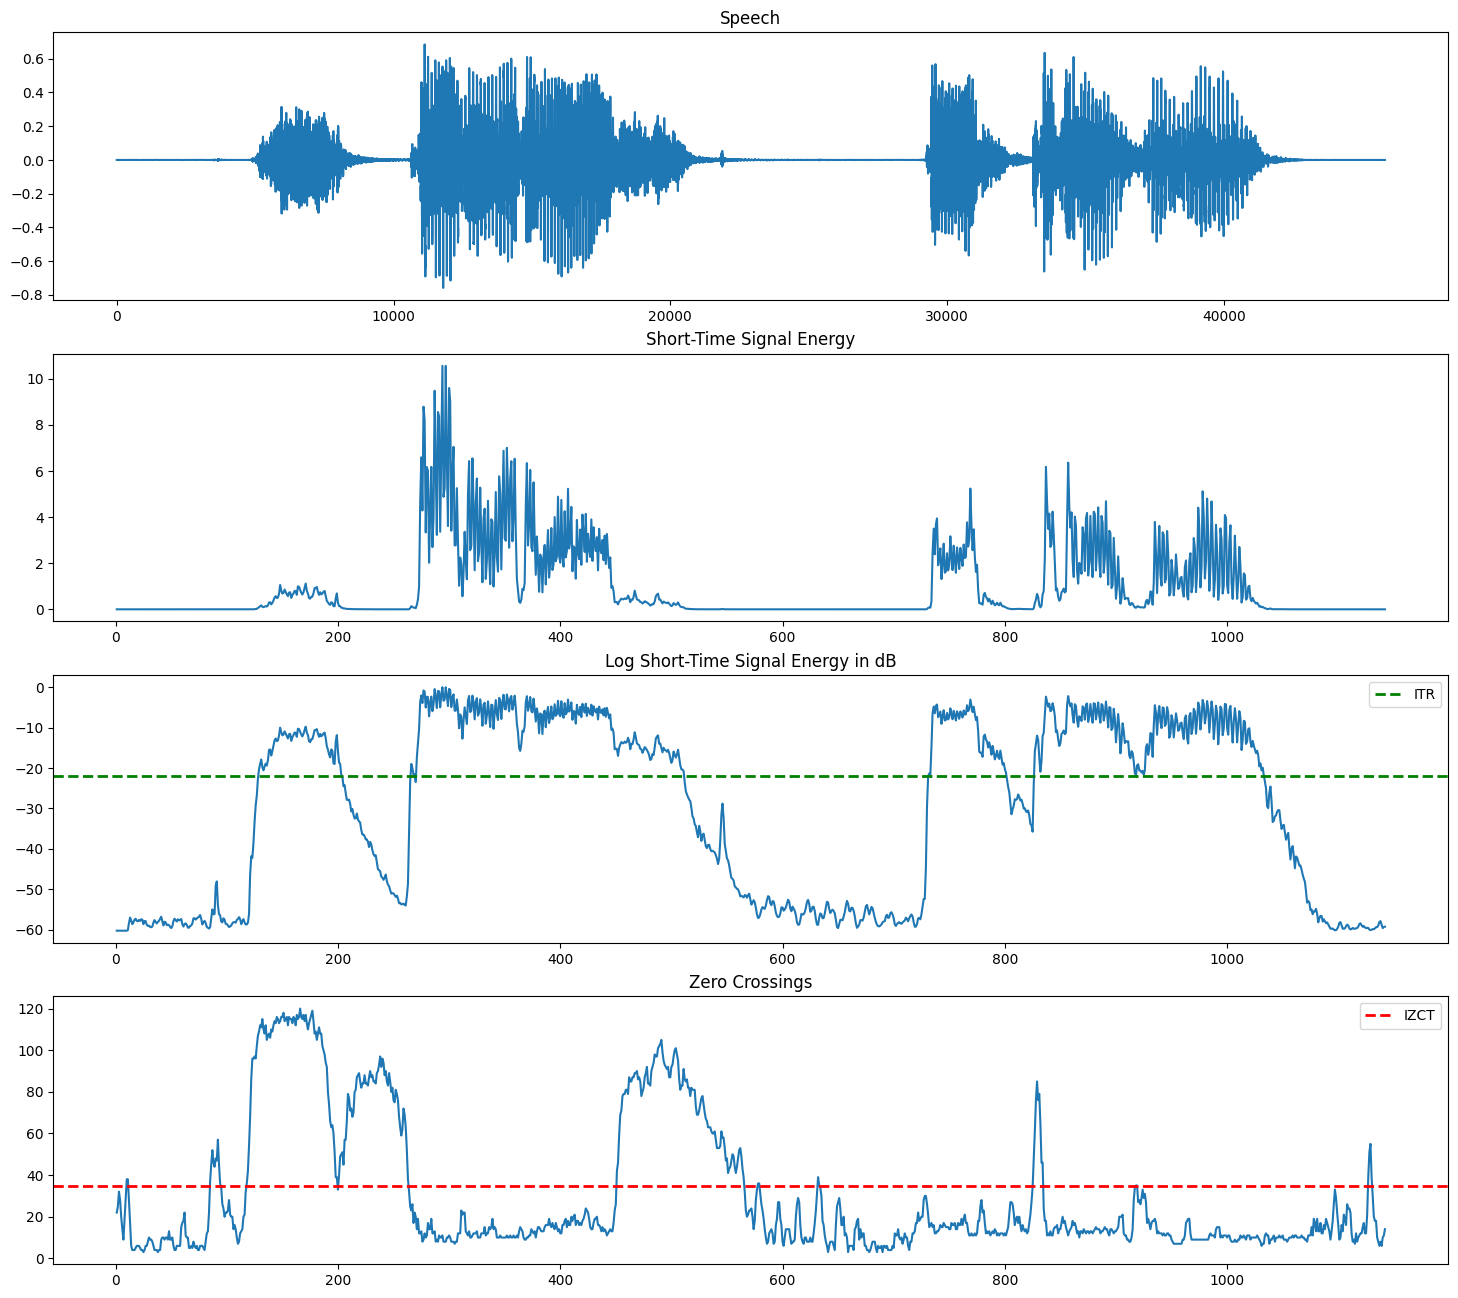

In [25]:
# Plot the Short-Time Energy of the whole signal

plt.figure(figsize=(18, 16))

plt.subplot(4, 1, 1)
pd.Series(clear_speech_signal).plot()
plt.title("Speech")

plt.subplot(4, 1, 2)
plt.plot(frame_num, speech_energy)
plt.title("Short-Time Signal Energy")

plt.subplot(4, 1, 3)
plt.plot(frame_num, log_speech_energy_db)
plt.axhline(y=ITR, color='g', linestyle='--', linewidth=2, label='ITR')
plt.legend()
plt.title("Log Short-Time Signal Energy in dB")

plt.subplot(4, 1, 4)
plt.plot(frame_num, speech_zc)
plt.axhline(y=IZCT, color='r', linestyle='--', linewidth=2, label='IZCT')
plt.legend()
plt.title("Zero Crossings")

plt.show()

In [26]:
# Apply the Voiced/Unvoiced Classification Function to Classify the frames as Voiced or Unvoiced
unvoiced_frames, voiced_frames = voiced_unvoiced_frame_classification(frame_num, speech_zc, log_speech_energy_db, IZCT, ITR)

# And after that, it's time to classify samples too
# Call the function classify_samples seperately for voiced and unvoiced frames
temp_voiced_samples = classify_samples(voiced_frames, FRAME_LENGTH, HOP_LENGTH)
unvoiced_samples = classify_samples(unvoiced_frames, FRAME_LENGTH, HOP_LENGTH)

# I will give again higher priority to Unvoiced segments, so I will remove the duplicates from the voiced list
duplicates = set(unvoiced_samples) & set(temp_voiced_samples)

voiced_samples_set = set(temp_voiced_samples) - set(duplicates)
voiced_samples = sorted(list(voiced_samples_set))

In [27]:
# Some useful prints to verify that my algorithm works so far

print(f"Number of Frames that have been classified as Unvoiced: {len(unvoiced_frames)}")
print(f"Number of Frames that have been classified as Voiced: {len(voiced_frames)}")

print(f"First 20 Unvoiced Frames: {unvoiced_frames[0:20]}")
print(f"First 20 Voiced Frames: {voiced_frames[0:20]}")

print(f"Number of Samples that have been classified as Unvoiced: {len(unvoiced_samples)}")
print(f"Unique Values in the array that contains the Unvoiced Samples: {len(set(unvoiced_samples))}")

print(f"Number of Samples that have been classified as Voiced: {len(temp_voiced_samples)}")
print(f"Unique Values in the array that contains the Voiced Samples: {len(set(temp_voiced_samples))}")

print(f"Total Number of Samples that are located in both arrays: {len(duplicates)}")

print(f"Number of Frames Samples in the Voiced array after the removal of the Duplicates: {len(voiced_samples)}")
print(f"The Intersection between the Voiced and Unvoiced array (It should be zero): {len(set(unvoiced_samples) & set(voiced_samples))}")

print("\n##\n")
print("As we can see, all values in both sample arrays are unique, and there is no sample that has been classified as voiced and unvoiced after the removal of the duplicates")

Number of Frames that have been classified as Unvoiced: 288
Number of Frames that have been classified as Voiced: 453
First 20 Unvoiced Frames: [10, 11, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 118, 119, 120, 121, 122, 123, 124, 125]
First 20 Voiced Frames: [200, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285]
Number of Samples that have been classified as Unvoiced: 12520
Unique Values in the array that contains the Unvoiced Samples: 12520
Number of Samples that have been classified as Voiced: 18680
Unique Values in the array that contains the Voiced Samples: 18680
Total Number of Samples that are located in both arrays: 440
Number of Frames Samples in the Voiced array after the removal of the Duplicates: 18240
The Intersection between the Voiced and Unvoiced array (It should be zero): 0

##

As we can see, all values in both sample arrays are unique, and there is no sample that has been classified as voiced and unvoiced after the removal o

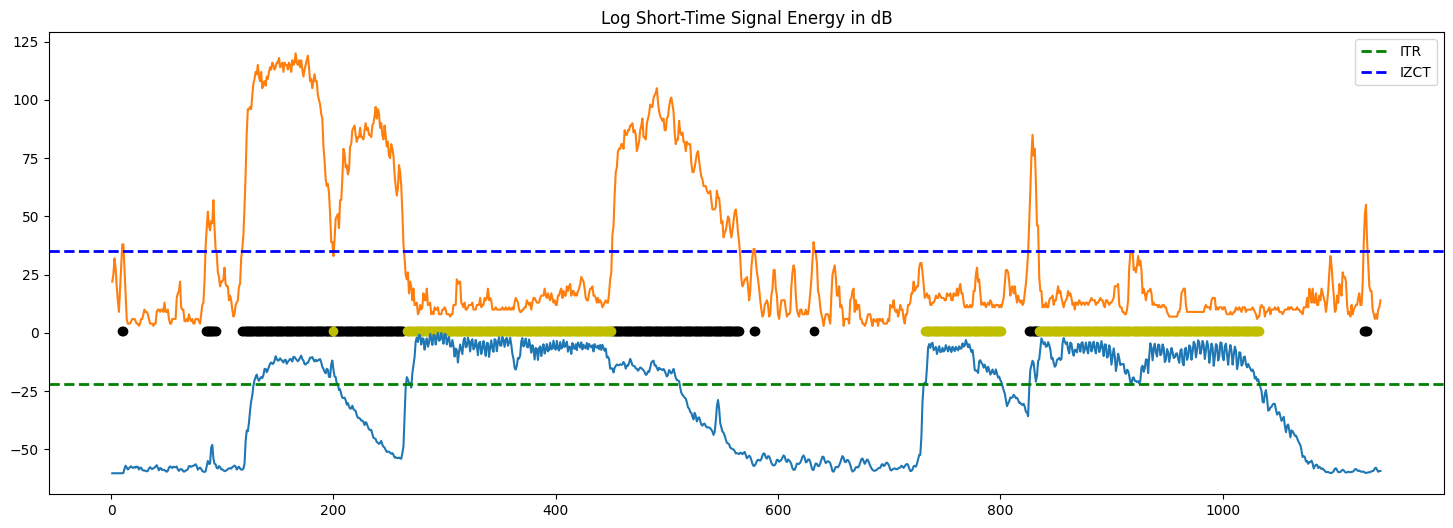

In [28]:
# A first check to see if the algorithm is working
plt.figure(figsize=(18, 6))

plt.plot(frame_num, log_speech_energy_db)
plt.plot(frame_num, speech_zc)
plt.scatter(unvoiced_frames, np.ones_like(unvoiced_frames), color='k')
plt.scatter(voiced_frames, np.ones_like(voiced_frames), color='y')
plt.axhline(y=ITR, color='g', linestyle='--', linewidth=2, label='ITR')
plt.axhline(y=IZCT, color='b', linestyle='--', linewidth=2, label='IZCT')
plt.legend()
plt.title("Log Short-Time Signal Energy in dB")

plt.show()

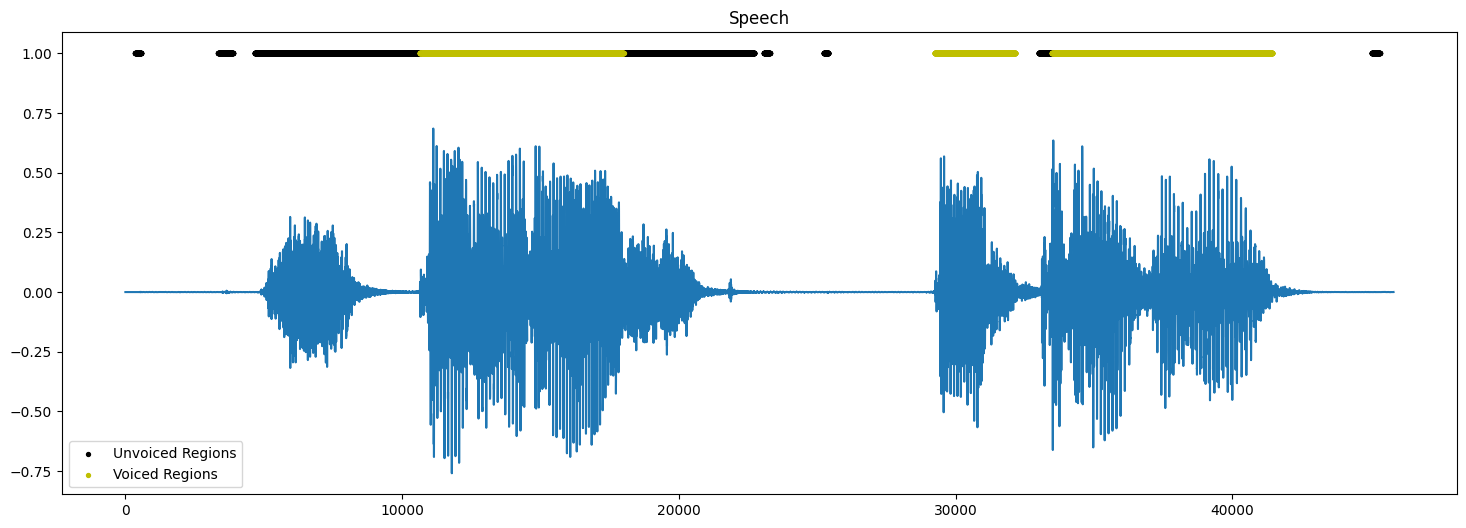

In [29]:
# Let's check it in the speech signal too
plt.figure(figsize=(18, 6))
pd.Series(clear_speech_signal).plot()
plt.scatter(unvoiced_samples, np.ones_like(unvoiced_samples), color='k', label='Unvoiced Regions', s=8)
plt.scatter(voiced_samples, np.ones_like(voiced_samples), color='y', label='Voiced Regions', s=8)
plt.legend()
plt.title("Speech")
plt.show()

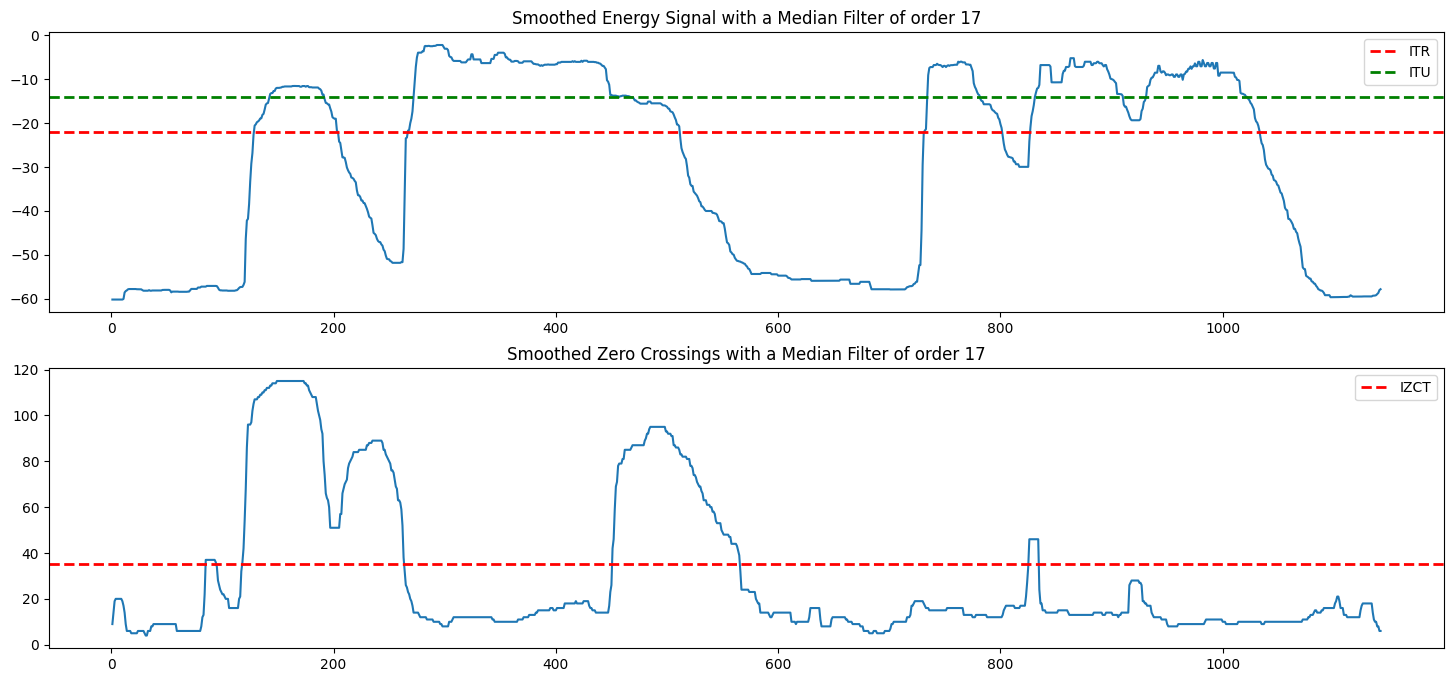

In [30]:
# The results are not bad at all, but I can improve my algorithm to remove some outliers, and fill in some 'gaps' between regions of the same class
# That's why I will apply a median filter in both Energy and Zero Crossings
smooth_energy_output, smooth_zc_output = median_filter(log_speech_energy_db, speech_zc, KSIZE)

# Plot the smoothed signal
plt.figure(figsize=(18, 8))

plt.subplot(2, 1, 1)
plt.plot(frame_num, smooth_energy_output)
plt.axhline(y=ITR, color='r', linestyle='--', linewidth=2, label='ITR')
plt.axhline(y=ITU, color='g', linestyle='--', linewidth=2, label='ITU')
plt.title(f'Smoothed Energy Signal with a Median Filter of order {KSIZE}')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(frame_num, smooth_zc_output)
plt.axhline(y=IZCT, color='r', linestyle='--', linewidth=2, label='IZCT')
plt.title(f'Smoothed Zero Crossings with a Median Filter of order {KSIZE}')
plt.legend()

plt.show()

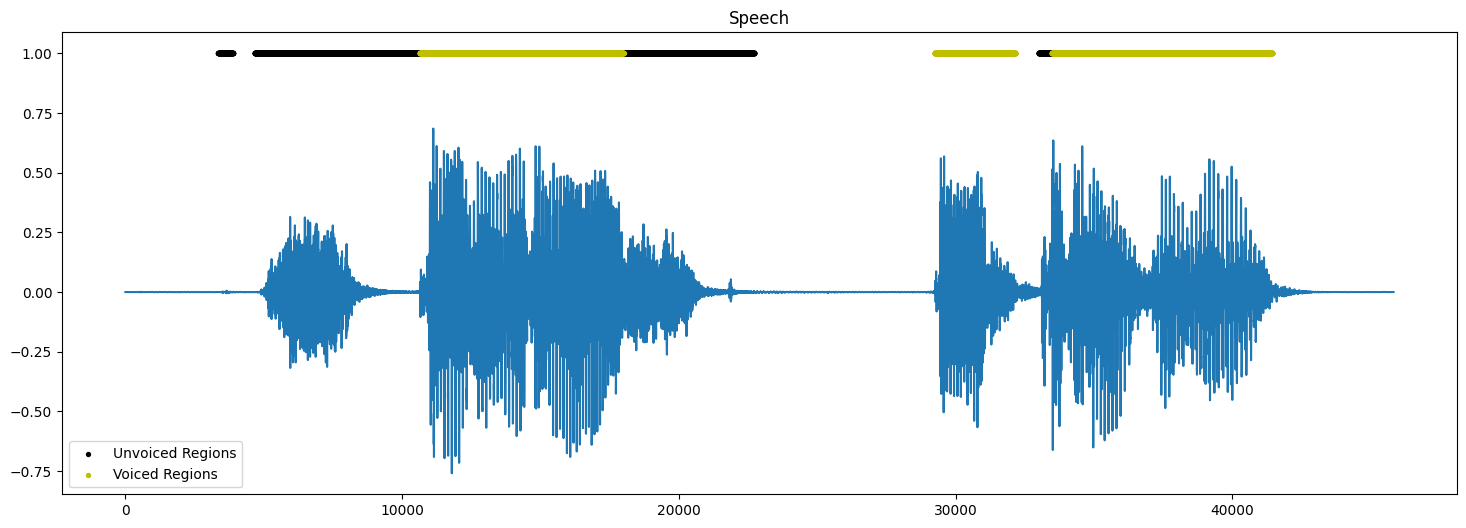

In [31]:
# Let's see the results in the smooth signals
# Apply the Voiced/Unvoiced Classification Function to Classify the frames as Voiced or Unvoiced, but using the smooth signals
smooth_unvoiced_frames, smooth_voiced_frames = voiced_unvoiced_frame_classification(frame_num, smooth_zc_output, smooth_energy_output, IZCT, ITR)

# Call the function classify_samples seperately for voiced and unvoiced frames, again using the smooth signals
smooth_temp_voiced_samples = classify_samples(smooth_voiced_frames, FRAME_LENGTH, HOP_LENGTH)
smooth_unvoiced_samples = classify_samples(smooth_unvoiced_frames, FRAME_LENGTH, HOP_LENGTH)

# I will give again higher priority to Unvoiced segments, so I will remove the duplicates from the voiced list
duplicates = set(smooth_unvoiced_samples) & set(smooth_temp_voiced_samples)

smooth_voiced_samples_set = set(smooth_temp_voiced_samples) - set(duplicates)
smooth_voiced_samples = sorted(list(smooth_voiced_samples_set))

# And it's time to see the new sample classification
plt.figure(figsize=(18, 6))
pd.Series(clear_speech_signal).plot()
plt.scatter(smooth_unvoiced_samples, np.ones_like(smooth_unvoiced_samples), color='k', label='Unvoiced Regions', s=8)
plt.scatter(smooth_voiced_samples, np.ones_like(smooth_voiced_samples), color='y', label='Voiced Regions', s=8)
plt.legend(loc='lower left')
plt.title("Speech")
plt.show()

In [32]:
# The results are much better than before. Some regions have been united and most of the outliers have been eliminated. However, it has failed to clssify 
#    correctly a part of the stop consonant /t/ in the middle of the surname, and it has failed fully to find the unvoiced stop consonant /p/, in the begining of the surname

In [33]:
# Now, before proceeding in the Pitch Detection Algorithm, I will apply a simple algorithm to discriminate speech from backgound using Short-Time log Energy and Short-Time
#     Zero Crossing Rate, that is descibed in the Chapter 10 of Rabiner and Schafer book. This algorithm is implemented in 'speech_silence_discrimination_func' function

# For better results, I will call the function using the smoothed signals
B1, E1, B2, E2 = speech_silence_discrimination_func(smooth_energy_output, smooth_zc_output, ITU, ITR, IZCT)

print(f'Begin Point Detected from the Algorithm: {B2}')
print(f'End Point Detected from the Algorithm: {E2}')

Begin Point Detected from the Algorithm: 117
End Point Detected from the Algorithm: 1032


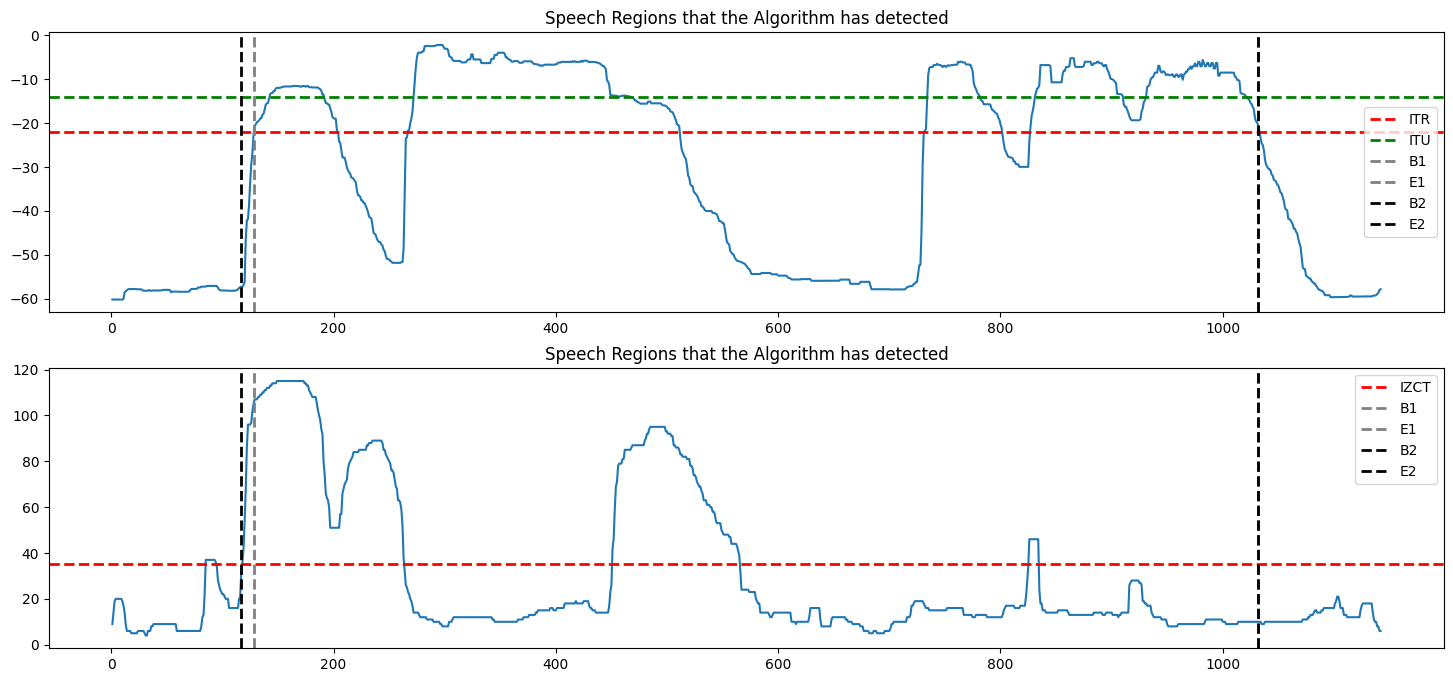

In [34]:
# Plot all the points that the algorithm has found (final points will be plotted with a darker colour)
plt.figure(figsize=(18, 8))

plt.subplot(2, 1, 1)
plt.plot(frame_num, smooth_energy_output)
plt.axhline(y=ITR, color='r', linestyle='--', linewidth=2, label='ITR')
plt.axhline(y=ITU, color='g', linestyle='--', linewidth=2, label='ITU')
plt.axvline(x=B1, color='gray', linestyle='--', linewidth=2, label='B1')
plt.axvline(x=E1, color='gray', linestyle='--', linewidth=2, label='E1')
plt.axvline(x=B2, color='k', linestyle='--', linewidth=2, label='B2')
plt.axvline(x=E2, color='k', linestyle='--', linewidth=2, label='E2')
plt.title(f'Speech Regions that the Algorithm has detected')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(frame_num, smooth_zc_output)
plt.axhline(y=IZCT, color='r', linestyle='--', linewidth=2, label='IZCT')
plt.axvline(x=B1, color='gray', linestyle='--', linewidth=2, label='B1')
plt.axvline(x=E1, color='gray', linestyle='--', linewidth=2, label='E1')
plt.axvline(x=B2, color='k', linestyle='--', linewidth=2, label='B2')
plt.axvline(x=E2, color='k', linestyle='--', linewidth=2, label='E2')
plt.title(f'Speech Regions that the Algorithm has detected')
plt.legend()

plt.show()

In [35]:
# Keep only the signal inside the interval [B2, E2] and hear it to verify that the algorithm works

# Find the samples inside the interval [B2, E2]
sample_begin = HOP_LENGTH * (B2-1)
sample_end = HOP_LENGTH * (E2-1) + FRAME_LENGTH

discriminated_speech = clear_speech_signal[sample_begin:sample_end]

# Cut also undesired entries from the voiced/unvoiced vectors
discriminated_voiced_samples = smooth_voiced_samples
discriminated_unvoiced_samples = smooth_unvoiced_samples

# Set all values that are going to be removed to 0 before cutting them
for i in range(len(smooth_voiced_samples)):
    if smooth_voiced_samples[i] < sample_begin or smooth_voiced_samples[i] > sample_end:
        discriminated_voiced_samples[i] = 0

for i in range(len(smooth_unvoiced_samples)):
    if smooth_unvoiced_samples[i] < sample_begin or smooth_unvoiced_samples[i] > sample_end:
        discriminated_unvoiced_samples[i] = 0

# Then cut all zero values
while 0 in discriminated_voiced_samples:
    discriminated_voiced_samples.remove(0)
    
while 0 in discriminated_unvoiced_samples:
    discriminated_unvoiced_samples.remove(0)
    
# And finally, shift all samples to the left by sample_begin samples, to match with the recorder signal
for i in range(len(discriminated_unvoiced_samples)):
    discriminated_unvoiced_samples[i] -= sample_begin
    
for i in range(len(discriminated_voiced_samples)):
    discriminated_voiced_samples[i] -= sample_begin


In [36]:
# Hear the cut signal to verify that the algorithm works well
ipd.Audio(discriminated_speech, rate=sr)

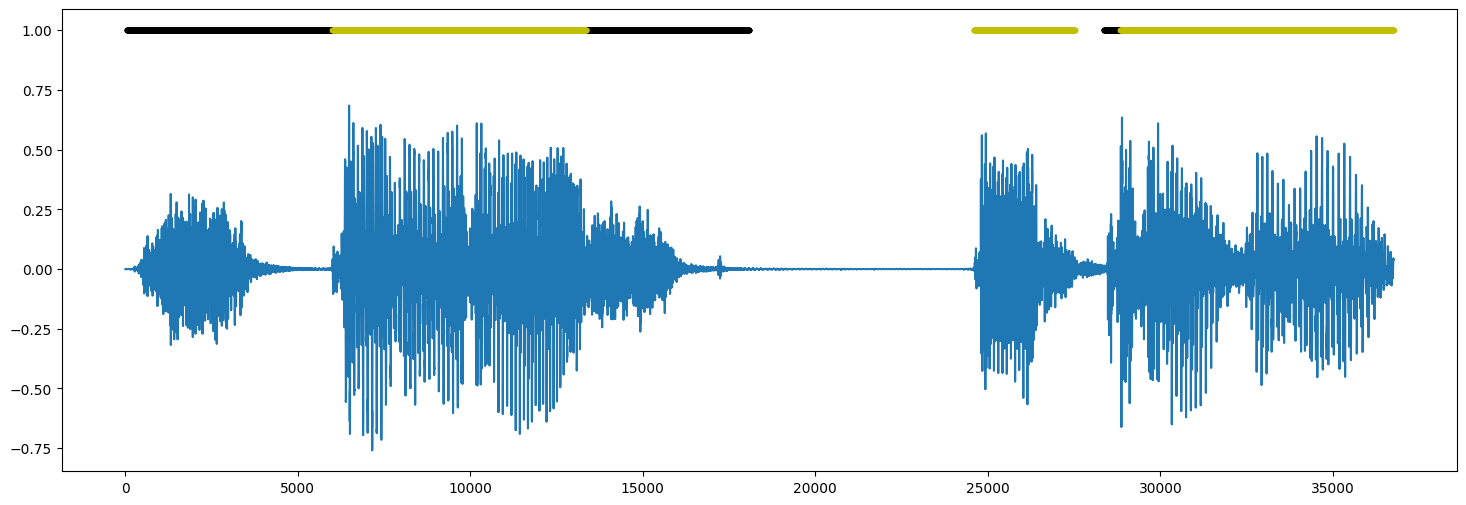

In [37]:
# Now plot the cut signal
pd.Series(discriminated_speech).plot(figsize=(18,6))
plt.scatter(discriminated_unvoiced_samples, np.ones_like(discriminated_unvoiced_samples), color='k', label='Unvoiced Regions', s=8)
plt.scatter(discriminated_voiced_samples, np.ones_like(discriminated_voiced_samples), color='y', label='Voiced Regions', s=8)
plt.show()

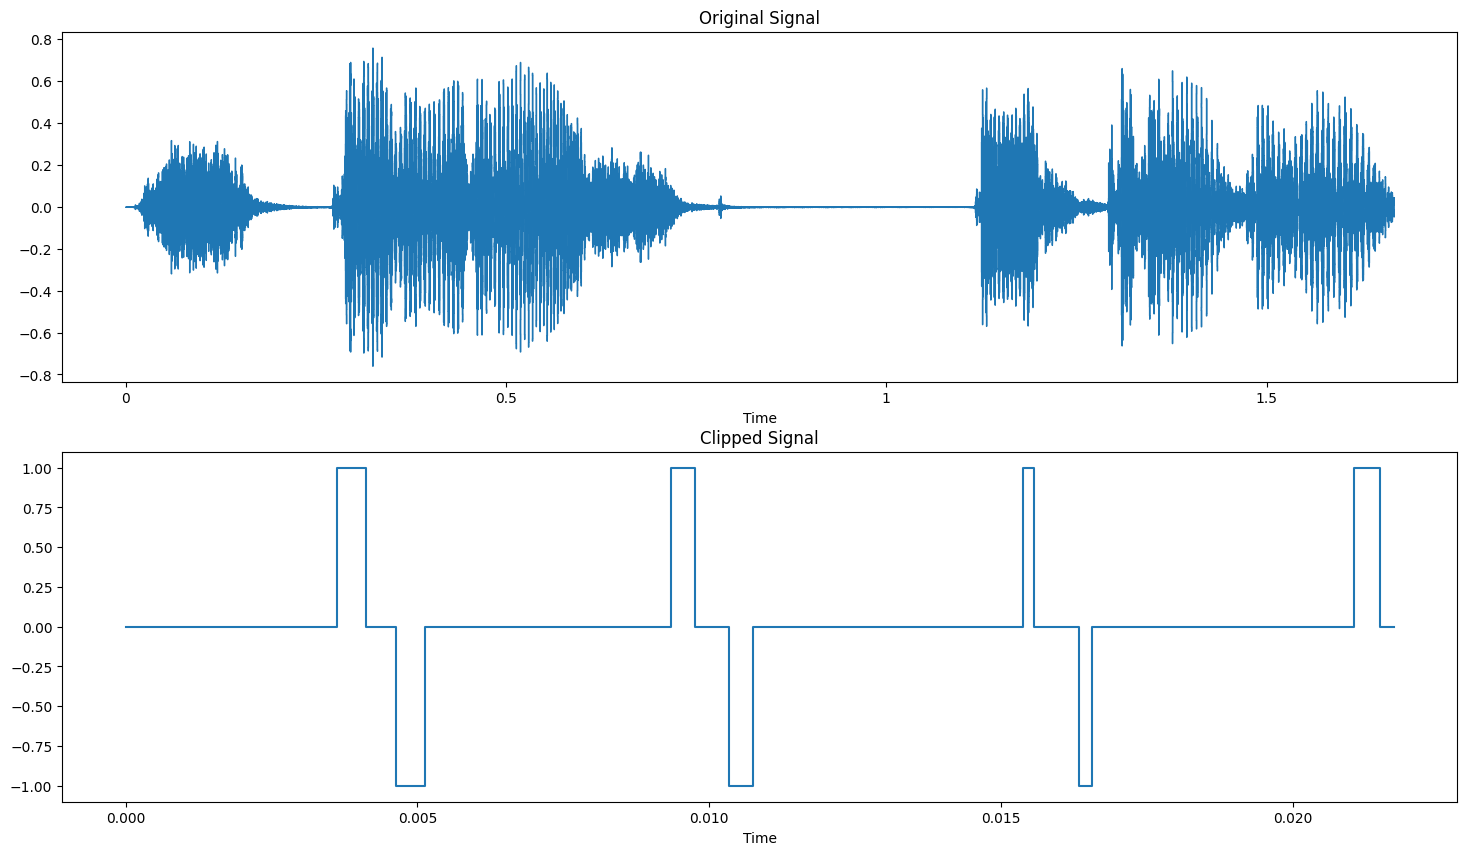

In [38]:
# Use the custom-made function for applying 3-level Center Clipping and Autocorrelation in the clipped signal
clipped_signal, autocorr_clipped_signal = center_clipping_func(discriminated_speech, PITCH_FRAME_LENGTH, PITCH_HOP_LENGTH)

# Plot a part of the clipped signal
plt.figure(figsize=(18, 10))

plt.subplot(2, 1, 1)
librosa.display.waveshow(discriminated_speech)
plt.title("Original Signal")

plt.subplot(2, 1, 2)
librosa.display.waveshow(clipped_signal[:, 40])
plt.title("Clipped Signal")

plt.show()

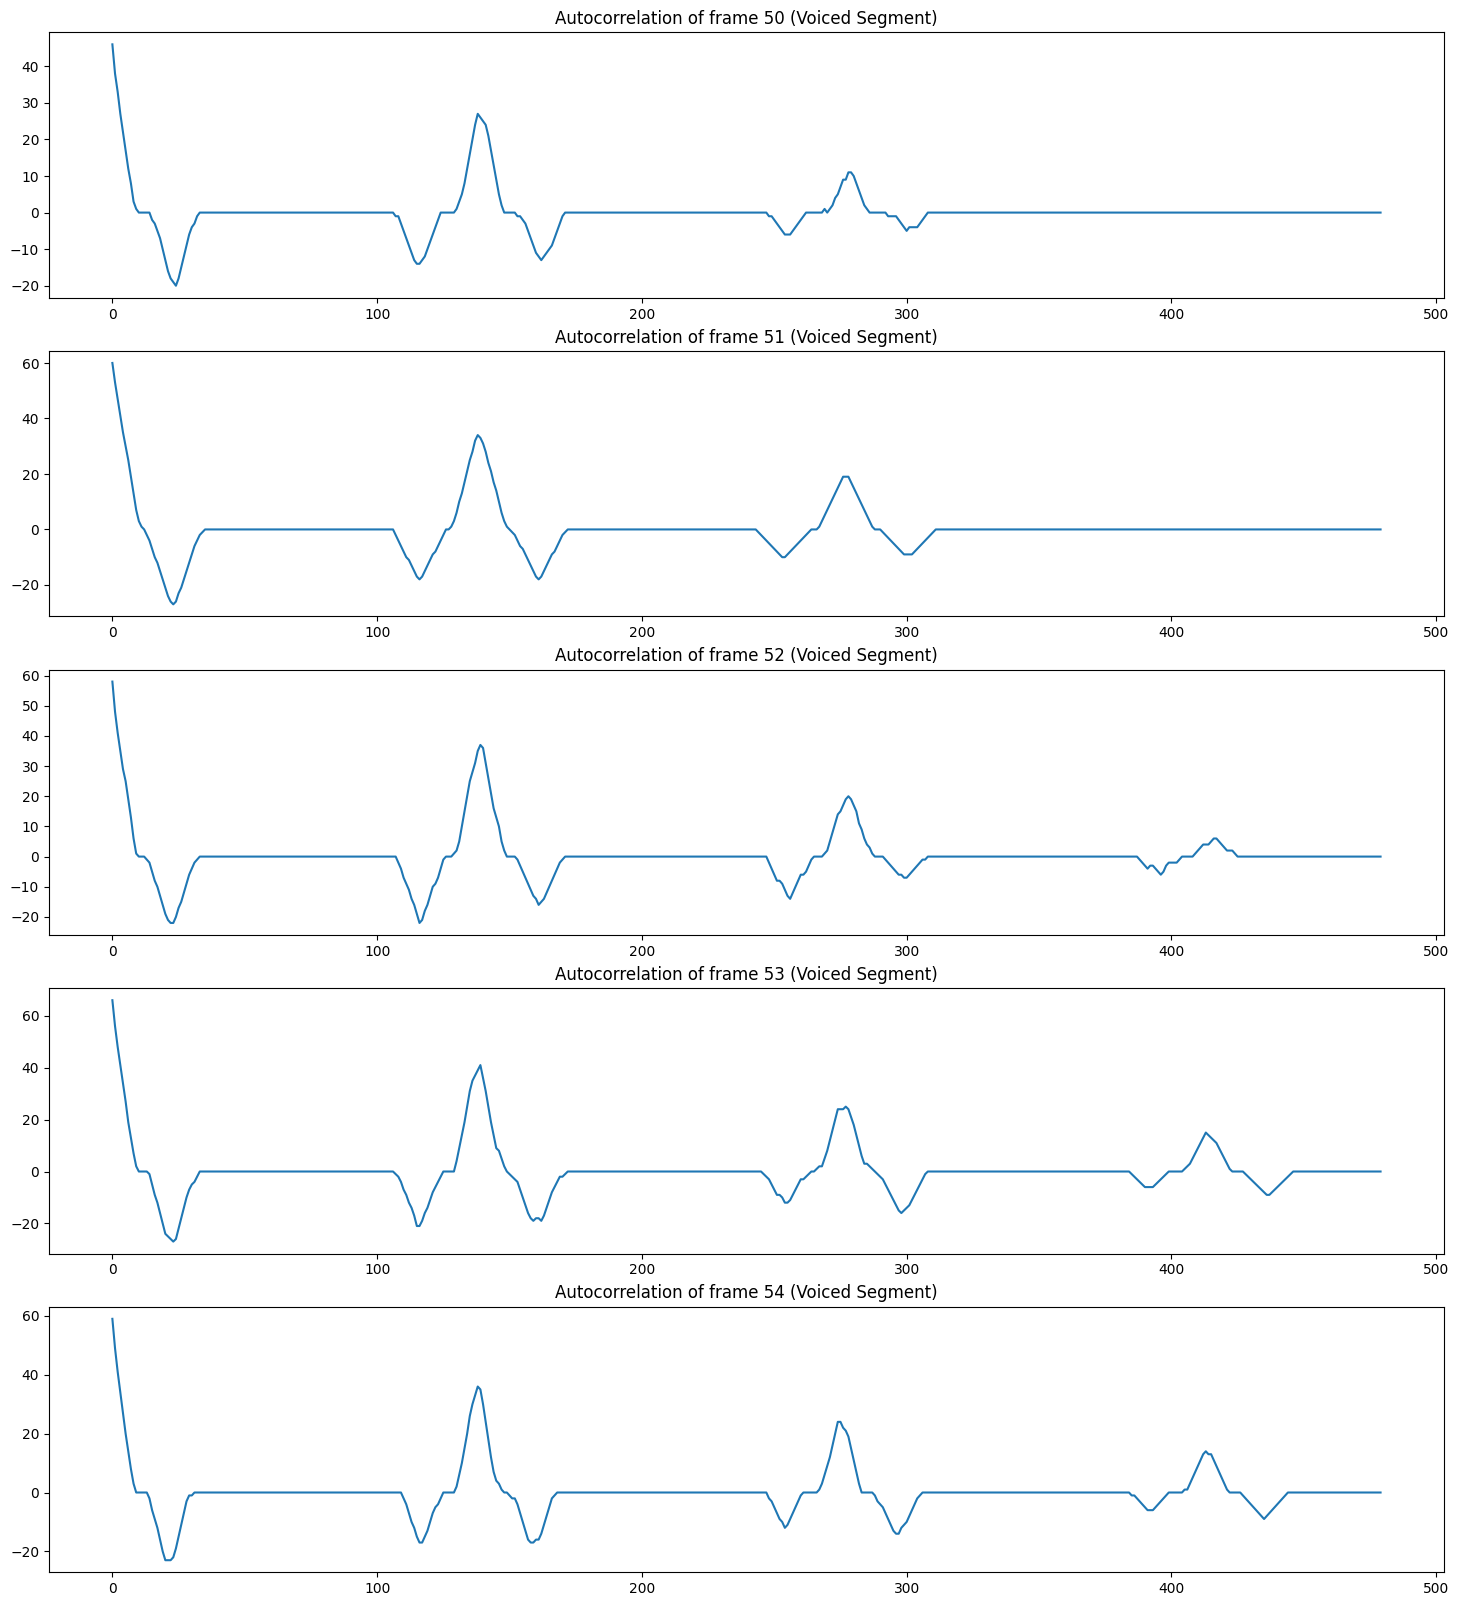

In [39]:
# Print the Output of the Autocorrelation Function from 5 Voiced Frames and from 5 Unvoiced Frames to see the Difference
plt.figure(figsize=(18, 20))

for i in range(5):
    plt.subplot(5, 1, i+1)
    pd.Series(autocorr_clipped_signal[:, (50+i)]).plot()
    plt.title(f"Autocorrelation of frame {50+i} (Voiced Segment)")

plt.show()

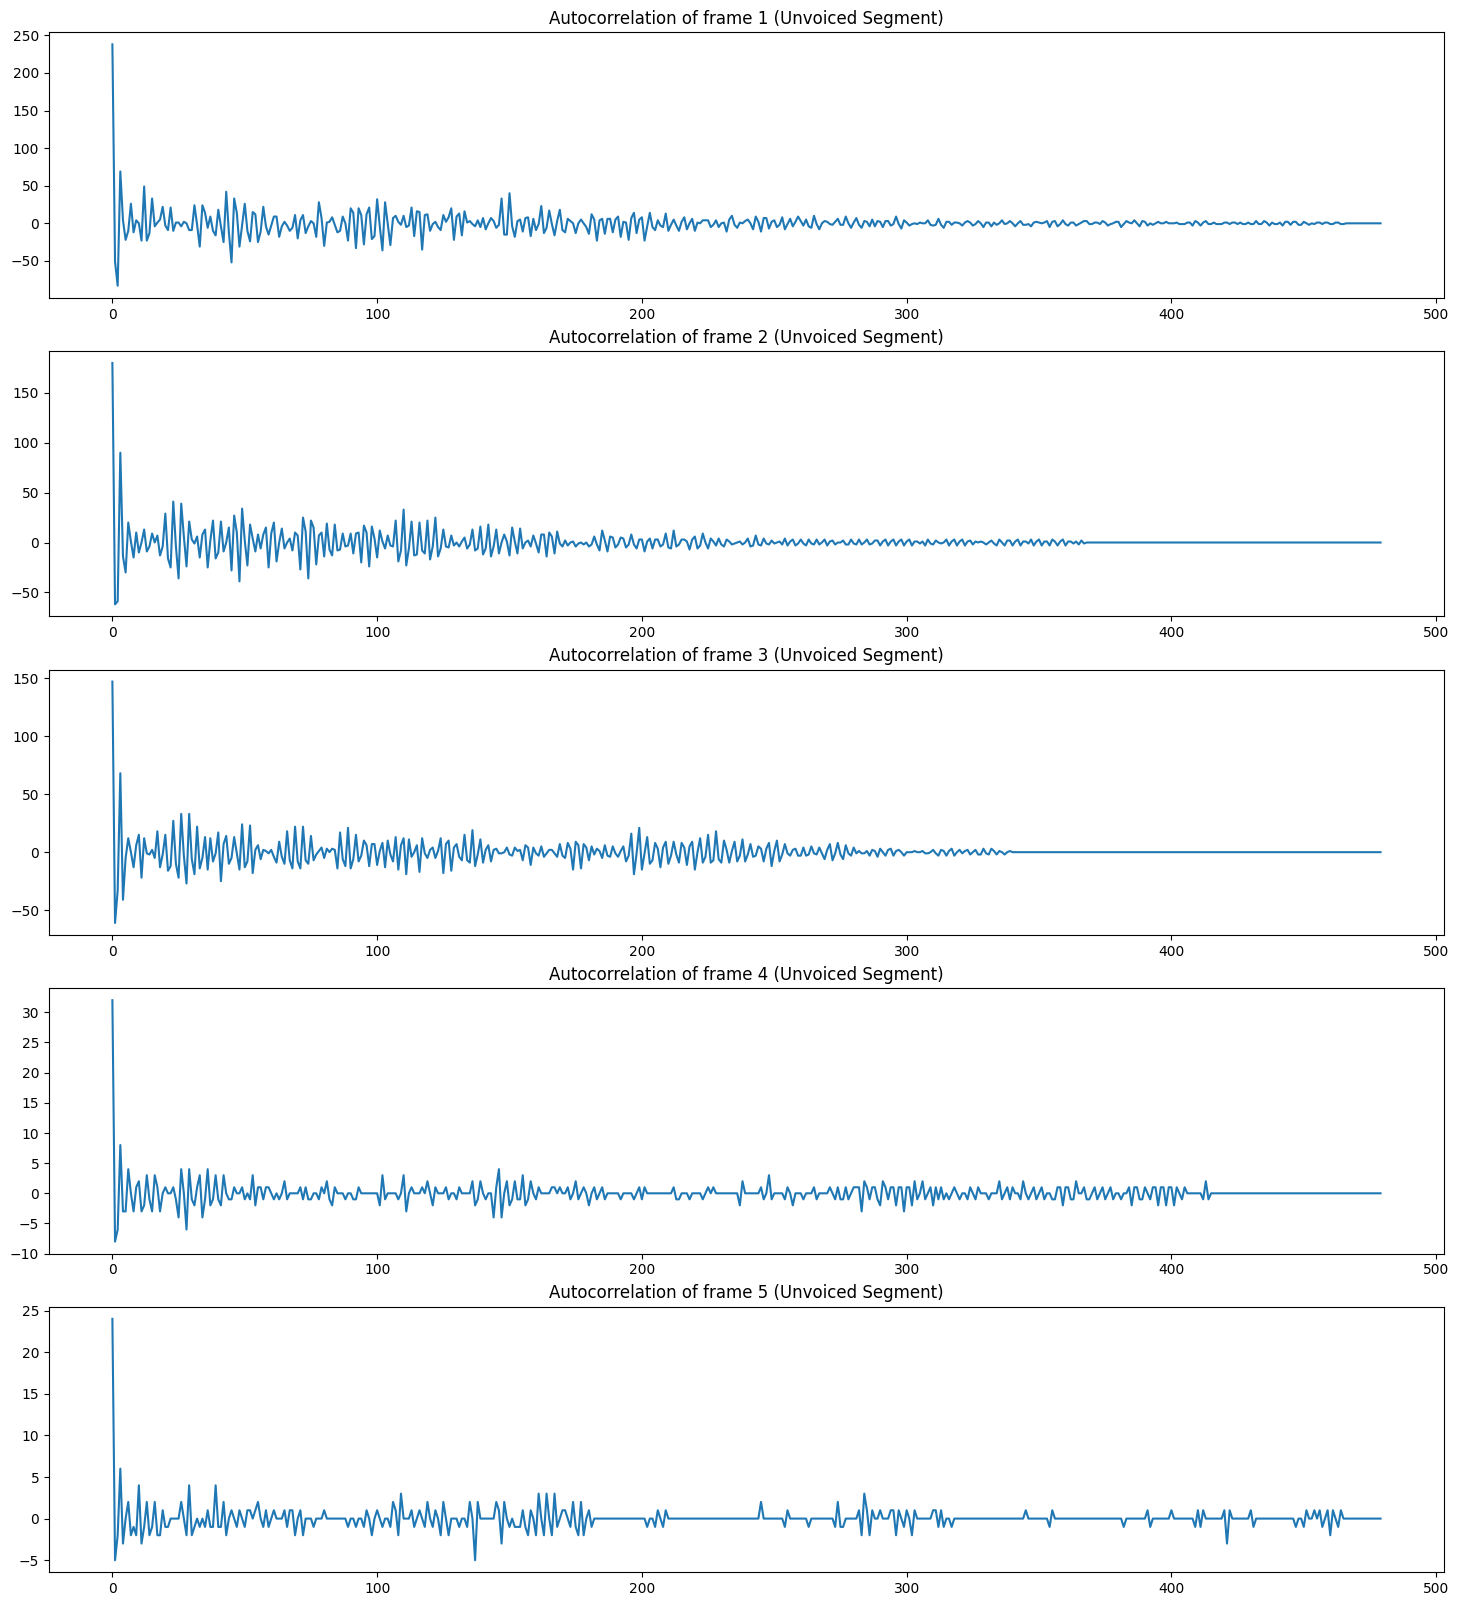

In [40]:
plt.figure(figsize=(18, 20))

for i in range(5):
    plt.subplot(5, 1, i+1)
    pd.Series(autocorr_clipped_signal[:, i]).plot()
    plt.title(f"Autocorrelation of frame {i+1} (Unvoiced Segment)")

plt.show()

In [41]:
# Use find_peaks function of scipy library to detect peaks. Set the height argument to 30% of the Rn[0] and classify them as 'Unvoiced'
rn = 0.3*autocorr_clipped_signal[0, :]

detected_peaks = []
for i in range(autocorr_clipped_signal.shape[1]):
    peaks, _ = find_peaks(autocorr_clipped_signal[:, i], height=rn[i])
    
    if len(peaks)>0: # That means that the algorithm found a peak above the threshold => Voiced Segment => Pitch Period is defined
        detected_peaks.append(peaks[0]) # Store the index in which the peak is found
    else: # If the peaks array is empty, it means that there is no value above the threshold => Unvoiced Segment => Pitch Period is not defined
        detected_peaks.append(0)
        
# One more detail: the Fundamental Frequency f0 is defined as Fs*(1/To) where Fs is the Sampling Rate and To is the Fundamental Period
# The Fundamental Period is equal to the distance from the beginning of a frame till the index that the peak is found
# Fortunately, this value is stored in detected_peaks list
f0 = np.zeros(len(detected_peaks))

for i in range(len(detected_peaks)):
    if detected_peaks[i] > 30: # Eliminate even more samples (assume that 30 samples are not enough to define f0), and avoid division by 0    
        f0[i] = sr * (1/np.array(detected_peaks[i]))

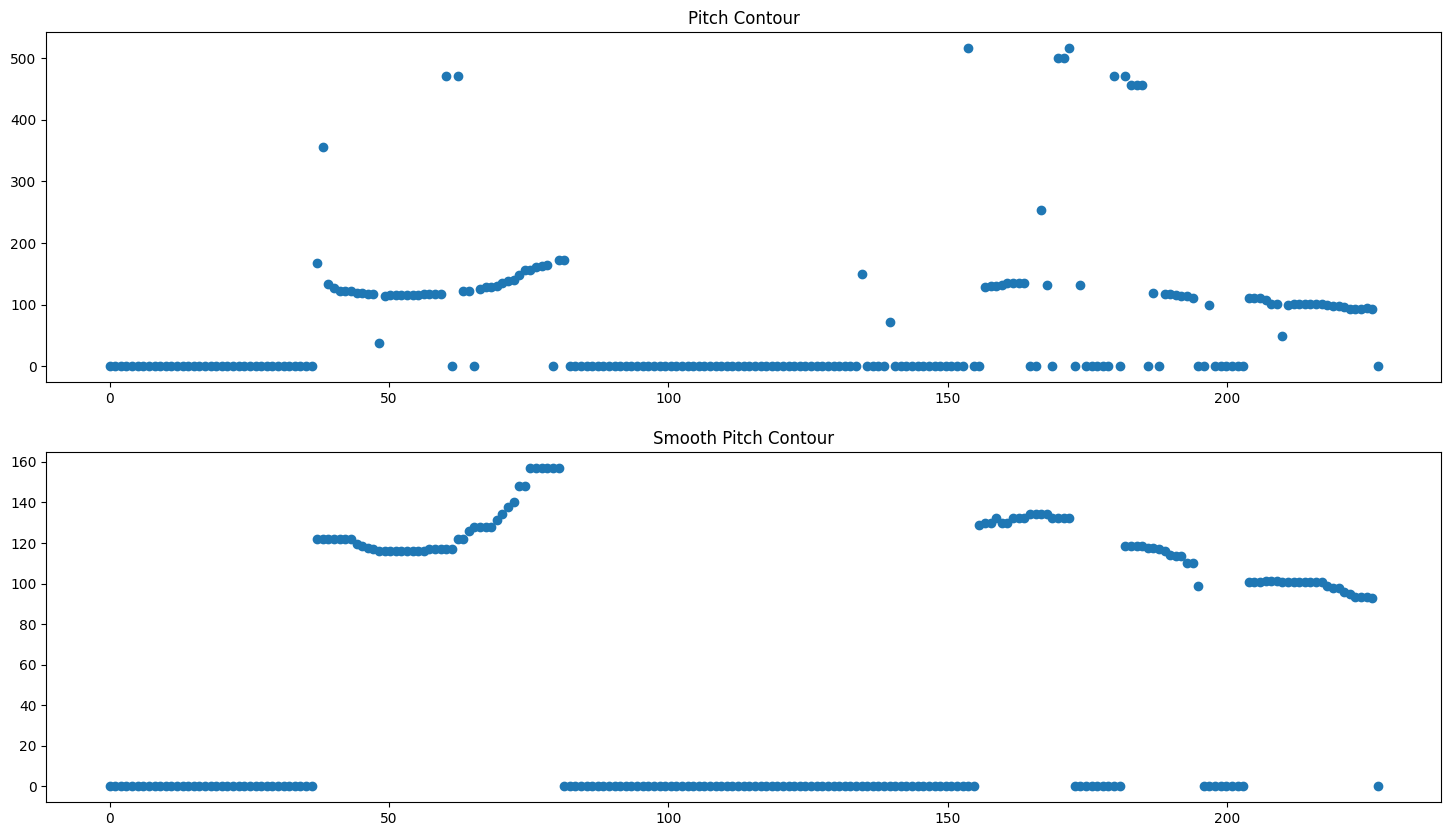

In [42]:
# Plot the Pitch Contour Before and After Smoothing with a Median Filter
pitch_frame_num = np.linspace(0, len(detected_peaks), len(detected_peaks))
f0_filt = medfilt(f0, kernel_size=11)

# And Plot Again the Pitch Contour
plt.figure(figsize=(18, 10))

plt.subplot(2, 1, 1)
plt.scatter(pitch_frame_num, f0)
plt.title("Pitch Contour")

plt.subplot(2, 1, 2)
plt.scatter(pitch_frame_num, f0_filt)
plt.title("Smooth Pitch Contour")

plt.show()

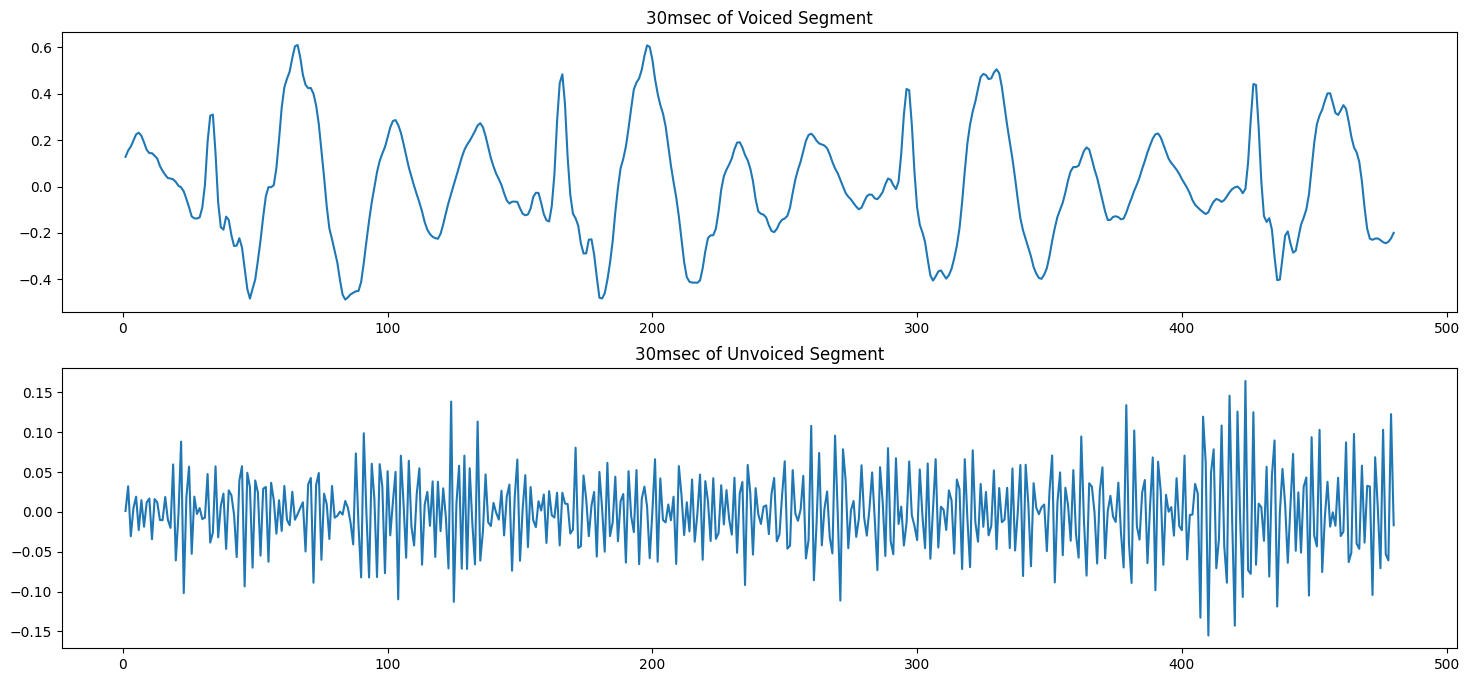

In [43]:
# Now it's time to find LPC coefficients for 30msec voiced segmanet ans 30msec unvoiced segment
# 30msec correspond to 480 samples in 16kHz sampling rate

lpc_voiced_segment = discriminated_speech[10120:10600]
lpc_unvoiced_segment = discriminated_speech[520:1000]
samples = np.linspace(1, lpc_voiced_segment.size, lpc_voiced_segment.size) # Same size as Unvoiced too

# Plot the extracted 480 samples
plt.figure(figsize=(18, 8))

plt.subplot(2, 1, 1)
plt.plot(samples, lpc_voiced_segment)
plt.title("30msec of Voiced Segment")

plt.subplot(2, 1, 2)
plt.plot(samples, lpc_unvoiced_segment)
plt.title("30msec of Unvoiced Segment")

plt.show()

In [44]:
# Call the 'create_autocorrelation_matrices' 3 times (for p=8,12,16)
toeplitz_voiced_array8, toeplitz_unvoiced_array8, voiced_target_vector8, unvoiced_target_vector8 = create_autocorrelation_matrices(lpc_voiced_segment, lpc_unvoiced_segment, 8)
toeplitz_voiced_array12, toeplitz_unvoiced_array12, voiced_target_vector12, unvoiced_target_vector12 = create_autocorrelation_matrices(lpc_voiced_segment, lpc_unvoiced_segment, 12)
toeplitz_voiced_array16, toeplitz_unvoiced_array16, voiced_target_vector16, unvoiced_target_vector16 = create_autocorrelation_matrices(lpc_voiced_segment, lpc_unvoiced_segment, 16)

# Solve the Ra=r => a=R^(-1)*r matrix equation, where R is the pxp Autocorrelation Matrix and r is the target vector
voiced8_coef = np.linalg.inv(toeplitz_voiced_array8) @ voiced_target_vector8.T
unvoiced8_coef = np.linalg.inv(toeplitz_unvoiced_array8) @ unvoiced_target_vector8.T

voiced12_coef = np.linalg.inv(toeplitz_voiced_array12) @ voiced_target_vector12.T
unvoiced12_coef = np.linalg.inv(toeplitz_unvoiced_array12) @ unvoiced_target_vector12.T

voiced16_coef = np.linalg.inv(toeplitz_voiced_array16) @ voiced_target_vector16.T
unvoiced16_coef = np.linalg.inv(toeplitz_unvoiced_array16) @ unvoiced_target_vector16.T

np.set_printoptions(linewidth=200)

# Print all coefficients obtained for p=8,12,16
print("LPC Coefficients for order p=8:")
print(voiced8_coef.round(5))
print(unvoiced8_coef.round(5))

print("\nLPC Coefficients for order p=12:")
print(voiced12_coef.round(5))
print(unvoiced12_coef.round(5))

print("\nLPC Coefficients for order p=16:")
print(voiced16_coef.round(5))
print(unvoiced16_coef.round(5))

LPC Coefficients for order p=8:
[ 2.17852 -1.61968  0.07901  0.56351  0.09246 -0.67994  0.48787 -0.15311]
[-1.28082 -1.79625 -1.13734 -1.04774 -0.3542  -0.40573 -0.05231 -0.19569]

LPC Coefficients for order p=12:
[ 2.09144 -1.4299  -0.05008  0.43867  0.26468 -0.52807  0.10525  0.00602  0.23575 -0.19844 -0.0166   0.00392]
[-1.17236 -1.75102 -0.93219 -1.05501 -0.20142 -0.52396  0.03816 -0.35452  0.14426  0.00414  0.23735  0.00312]

LPC Coefficients for order p=16:
[ 2.09404 -1.439   -0.05051  0.42613  0.28684 -0.47855  0.00314  0.0287   0.27232 -0.12184 -0.2185   0.18694 -0.1383   0.24704 -0.30826  0.1297 ]
[-1.13815 -1.79384 -0.83959 -1.06282  0.0474  -0.53888  0.29102 -0.43576  0.46267  0.02216  0.6348  -0.03418  0.07695 -0.40174 -0.20332 -0.24183]


In [45]:
# Call the function that computes MSE for all coeeficients that arose from the solution of the Autocorrelation Method
voiced8_mse = compute_mse(toeplitz_voiced_array8[0, 0], voiced8_coef, voiced_target_vector8, 8)
voiced12_mse = compute_mse(toeplitz_voiced_array12[0, 0], voiced12_coef, voiced_target_vector12, 12)
voiced16_mse = compute_mse(toeplitz_voiced_array16[0, 0], voiced16_coef, voiced_target_vector16, 16)

unvoiced8_mse = compute_mse(toeplitz_unvoiced_array8[0, 0], unvoiced8_coef, unvoiced_target_vector8, 8)
unvoiced12_mse = compute_mse(toeplitz_unvoiced_array12[0, 0], unvoiced12_coef, unvoiced_target_vector12, 12)
unvoiced16_mse = compute_mse(toeplitz_unvoiced_array16[0, 0], unvoiced16_coef, unvoiced_target_vector16, 16)

# Compute the gain as the square root of MSE
gain8_voiced = np.sqrt(voiced8_mse)
gain12_voiced = np.sqrt(voiced12_mse)
gain16_voiced = np.sqrt(voiced16_mse)
gain8_unvoiced = np.sqrt(unvoiced8_mse)
gain12_unvoiced = np.sqrt(unvoiced12_mse)
gain16_unvoiced = np.sqrt(unvoiced16_mse)

# Useful Prints
print(f"MSE for the Voiced Segment and p=8:  {voiced8_mse}, with Gain: {gain8_voiced}")
print(f"MSE for the Voiced Segment and p=12: {voiced12_mse}, with Gain: {gain12_voiced}")
print(f"MSE for the Voiced Segment and p=16: {voiced16_mse}, with Gain: {gain16_voiced}")

print("\n##\n")

print(f"MSE for the Unvoiced Segment and p=8:  {unvoiced8_mse}, with Gain: {gain8_unvoiced}")
print(f"MSE for the Unvoiced Segment and p=12: {unvoiced12_mse}, with Gain: {gain12_unvoiced}")
print(f"MSE for the Unvoiced Segment and p=16: {unvoiced16_mse}, with Gain: {gain16_unvoiced}")

MSE for the Voiced Segment and p=8:  0.3177743424373709, with Gain: 0.5637147704623064
MSE for the Voiced Segment and p=12: 0.2865009423549516, with Gain: 0.5352578279249651
MSE for the Voiced Segment and p=16: 0.27656016779273784, with Gain: 0.525889881812474

##

MSE for the Unvoiced Segment and p=8:  0.17537745884262246, with Gain: 0.41878091986457844
MSE for the Unvoiced Segment and p=12: 0.1506695991232494, with Gain: 0.38816182079546335
MSE for the Unvoiced Segment and p=16: 0.1335091678266216, with Gain: 0.36538906363850243


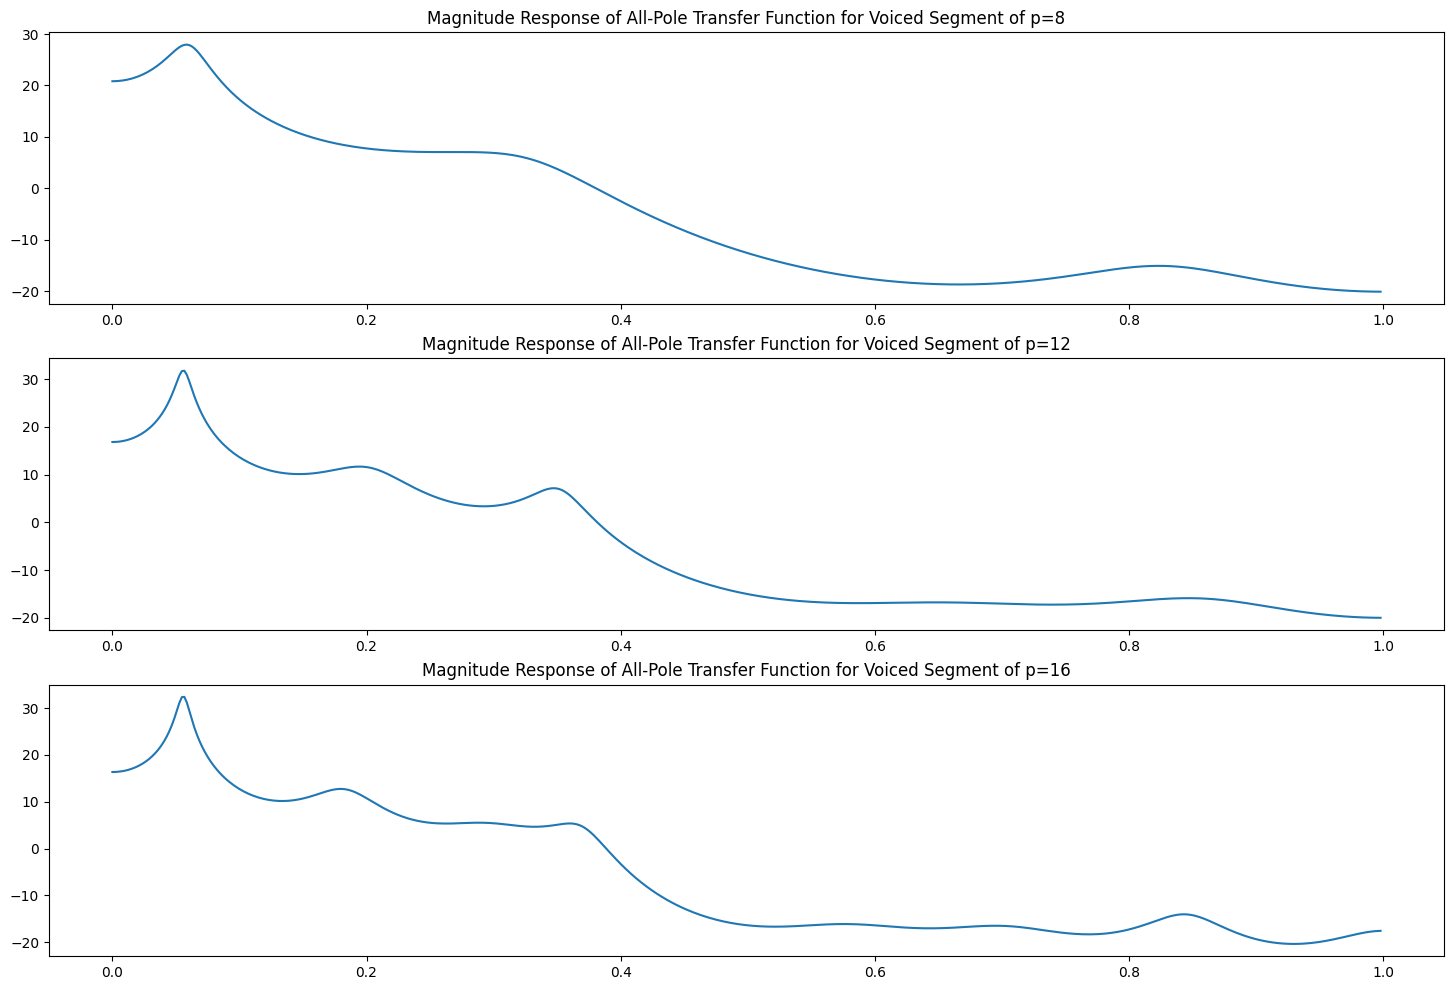

In [46]:
# Plot the Transfer Function for the Voiced Segments first
w8_voiced, h_magn8_voiced = all_pole_transfer_func(voiced8_coef, gain8_voiced)
w12_voiced, h_magn12_voiced = all_pole_transfer_func(voiced12_coef, gain12_voiced)
w16_voiced, h_magn16_voiced = all_pole_transfer_func(voiced16_coef, gain16_voiced)

# Plot the magnitude response
plt.figure(figsize=(18, 12))

plt.subplot(3, 1, 1)
plt.plot(w8_voiced/np.pi, 20*np.log10(h_magn8_voiced))
plt.title('Magnitude Response of All-Pole Transfer Function for Voiced Segment of p=8')

plt.subplot(3, 1, 2)
plt.plot(w12_voiced/np.pi, 20*np.log10(h_magn12_voiced))
plt.title('Magnitude Response of All-Pole Transfer Function for Voiced Segment of p=12')

plt.subplot(3, 1, 3)
plt.plot(w16_voiced/np.pi, 20*np.log10(h_magn16_voiced))
plt.title('Magnitude Response of All-Pole Transfer Function for Voiced Segment of p=16')

plt.show()

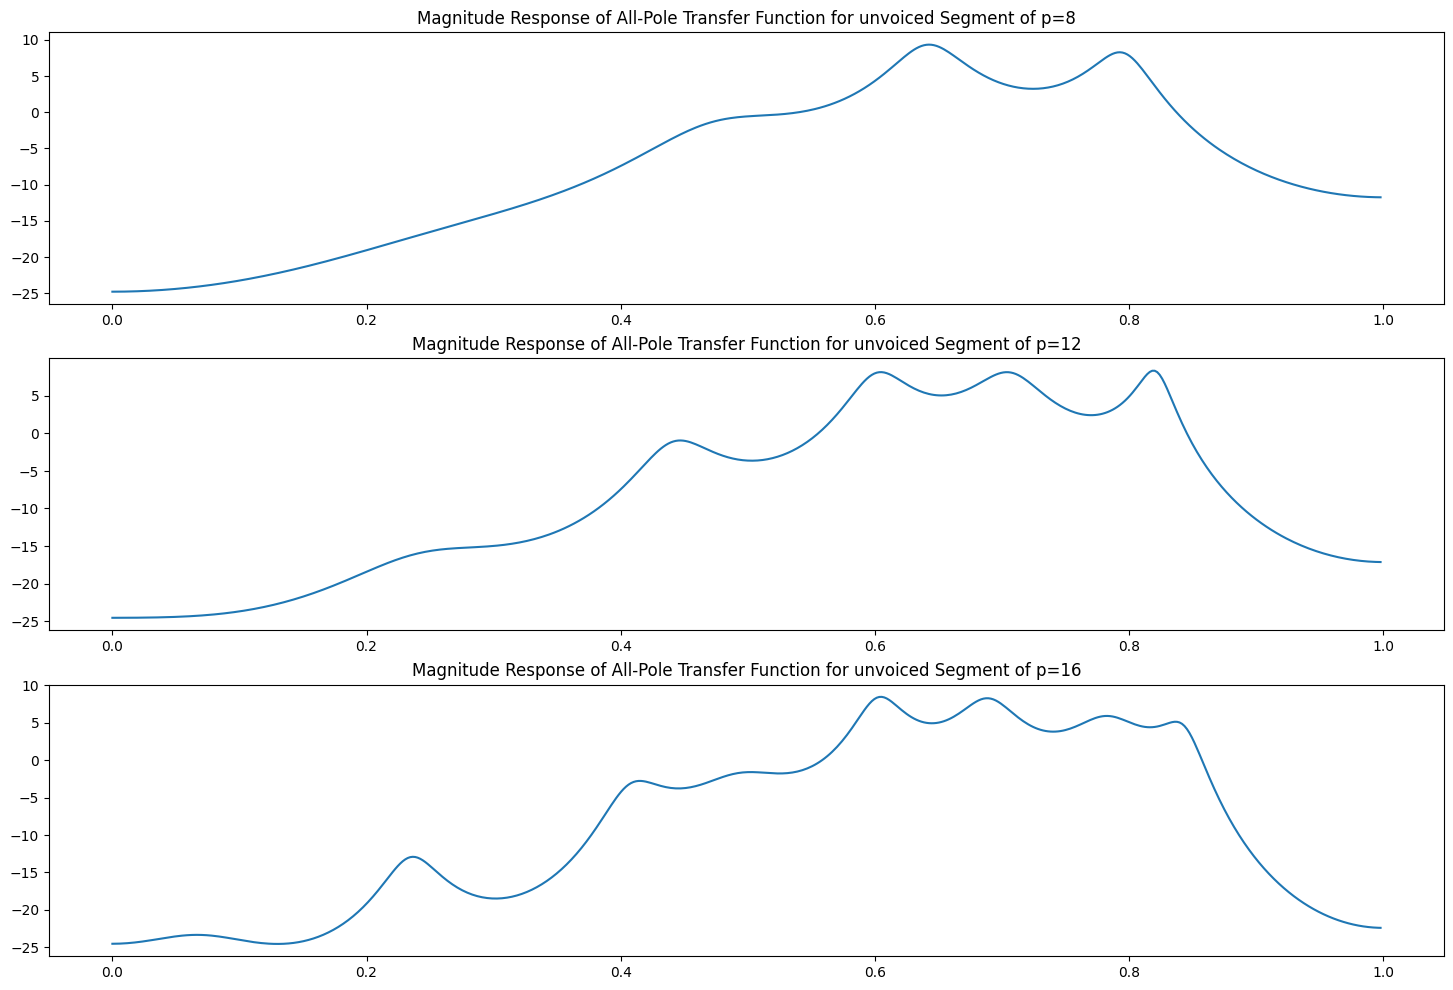

In [47]:
# And then, for the Unvoiced Segment
w8_unvoiced, h_magn8_unvoiced = all_pole_transfer_func(unvoiced8_coef, gain8_unvoiced)
w12_unvoiced, h_magn12_unvoiced = all_pole_transfer_func(unvoiced12_coef, gain12_unvoiced)
w16_unvoiced, h_magn16_unvoiced = all_pole_transfer_func(unvoiced16_coef, gain16_unvoiced)

# Plot the magnitude response
plt.figure(figsize=(18, 12))

plt.subplot(3, 1, 1)
plt.plot(w8_unvoiced/np.pi, 20*np.log10(h_magn8_unvoiced))
plt.title('Magnitude Response of All-Pole Transfer Function for unvoiced Segment of p=8')

plt.subplot(3, 1, 2)
plt.plot(w12_unvoiced/np.pi, 20*np.log10(h_magn12_unvoiced))
plt.title('Magnitude Response of All-Pole Transfer Function for unvoiced Segment of p=12')

plt.subplot(3, 1, 3)
plt.plot(w16_unvoiced/np.pi, 20*np.log10(h_magn16_unvoiced))
plt.title('Magnitude Response of All-Pole Transfer Function for unvoiced Segment of p=16')

plt.show()